# Práctica 04 : Análisis de datos exploratorio con python y jupiter notebook en un dataset de productos de amazon store

**Programa de estudios:** Ingenieria en Entornos Virtuales y Negocios Digitales \
**Asignatura:** Analítica de datos para negocios digitales \
**Docente:** M.T.I Marco A. Ramírez Hernández \
**Periodo:** Mayo - Agosto 2026

### Unidad 2: Preparación de los datos

**Nombre del Estudiante:** Liliana Rosales Gomez \
**Matricula:** 230370 \
**Grado y Grupo:** 9°A IEVND

<div style="background: linear-gradient(135deg, #0A4D8C 0%, #052C65 100%);
padding: 30px;
border-radius: 15px;
text-align: center;">

<h1 style="color: white; font-size: 2.2em; margin: 0;">
Productos de Amazon Store – Análisis Exploratorio de Datos
Completo & Aprendizaje Automático Predictivo (ML)
</h1>

<p style="color: #D6EAF8; font-size: 1.1em; margin-top: 10px;">  
Predicción de Precios • Análisis de Categorías •
Ingeniería de Funcionalidades • Comparación de Modelos
</p>

</div>

## Tabla de Contenidos
| # | Sección | Descripción |
|---|---|---|
| 1 |[Instalaciones & carga de datos](#s1). | Librerias, carga del CVS, primeros comandos de estructura |
| 2 |[Diccionario de datos](#s2) |Explicacion del contenido de columnas y calcular el % de datos faltantes |
| 3 |[Limpieza de datos](#s3) |Apliacion de metodos basicos de limpieza (eliminacion de duplicados,agrupacion y datos nulos) |
| 4 |[Ingenieria de Caracteristicas](#s4) |Transforma las variables originales en nuevas variables que pueden ser más útiles para el análisis |
| 5 |[Análisis Univariado](#s5) |Categorías principales, precio por categoría) |
| 6 |[Análisis de categorias](#s6) |Categorías principales, precio por categoría |
| 7 |[Análisis de disponibilidad](#s7) |Disponibilidad por productos|
| 8 |[Correlación y análisis bivariado](#s8) |Mapa de calor, diagramas de dispersión |
| 9 |[Pruebas de hipótesis estadísticas](#s9) |ANOVA, Kruskal-Wallis, Spearman |
| 10 |[Formulación del Problema de Machine Learning](#s10) |Predecir el precio del producto utilizando variables |
| 11 | [Marco de Selección de Modelos](#s11)      | Preparación y criterios para evaluar los modelos predictivos.    |
| 12 | [Modelos de Regresión](#s12)               | Entrenamiento de modelos de regresión para predecir precios.     |
| 13 | [Ajuste de Hiperparámetros](#s13)          | Optimización de parámetros para mejorar el rendimiento.          |
| 14 | [Comparación y Selección de Modelos](#s14) | Comparación de métricas y elección del mejor modelo.             |
| 15 | [Ideas Clave y Reporte de Negocio](#s15)   | Principales hallazgos y conclusiones para la toma de decisiones. |
| 15 | [Conclusion](#s15)   | Conclusion Personal del tema. |



## 1. Instalaciones & Carga de Datos <a id='s1'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">

<b>Dataset:</b> Amazon India Listas de Productos – 1,436 productos entre Libros, Kindle, Deportes & más<br>

<b>Objetivo:</b> Predecir el precio del producto (INR) desde la categoría, longitud del nombre, y disponibilidad<br>

<b>DataSource:</b> Web-scraped de páginas de productos Amazon.in

</div>

In [27]:
# ============================================================
# SECTION 1 — Setup & Data Loading
# ============================================================
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
from scipy import stats
from scipy.stats import shapiro, kruskal, spearmanr, mannwhitneyu, f_oneway

# ML
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except ImportError:
    XGB_AVAILABLE = False

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (13, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

print(f'✅ Pandas  : {pd.__version__}')
print(f'✅ NumPy   : {np.__version__}')
print(f'✅ XGBoost : {XGB_AVAILABLE}')
print('✅ All libraries loaded!')

✅ Pandas  : 2.3.3
✅ NumPy   : 2.3.5
✅ XGBoost : False
✅ All libraries loaded!


In [ ]:
df_raw = pd.read_csv('./amazon_products_data.csv', encoding='latin-1')

print(f"✅ Shape: {df_raw.shape}")
print(f"✅ Columns: {df_raw.columns.tolist()}")

df_raw.head(3)

✅ Shape: (1447, 17)
✅ Columns: ['rl', 'asin', 'name', 'overview', 'price', 'currency', 'availability', 'brand', 'about_item', 'img_source', 'description', 'specifications', 'primary_category', 'category_1', 'category_2', 'category_3', 'breadcrumbs']


,rl,asin,name,overview,price,currency,availability,brand,about_item,img_source,description,specifications,primary_category,category_1,category_2,category_3,breadcrumbs
0,https://www.amazon.in/dp/1788832566,1788832566,Hands-On Design Patterns with C++: Solve commo...,[],"1,600.00",INR,NaN,by \r\n Fedor G. Pikus (...,NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Computers & Internet,Programming & Software Development,NaN,Books | Computers & Internet | Programming & S...
1,https://www.amazon.in/dp/0766199592,0766199592,The Blazing Horizon The True Story of Pawnee B...,[],"2,399.00",INR,Usually dispatched in 13 to 14 days.,by \r\nErnest Lynn \r\n(Author),NaN,https://images-na.ssl-images-amazon.com/images...,NaN,[],Books,Action & Adventure,NaN,NaN,Books | Action & Adventure
2,https://www.amazon.in/dp/B071ZCD9XH,B071ZCD9XH,Fast and easy lunch box: A collection of 15eas...,[],NaN,NaN,NaN,by \r\nNinety Nine Cents Pr...,NaN,https://m.media-amazon.com/images/I/41g9Z21QuG...,NaN,[],Kindle Store,Kindle eBooks,"Crafts, Home & Lifestyle",NaN,"Kindle Store | Kindle eBooks | Crafts, Home & ..."


## 2.- Diccionario de datos del DataFrame. <a id='s2'></a>

In [28]:
col_info = {
    'url': 'URL del Producto en Amazon.in',
    'asin': 'Número Estandarizado de Identificación por Amazon (unique ID)',
    'name': 'Nombre o Título del Producto',
    'overview': 'Breve Reseña del Producto (mayoría vacío [])',
    'price': 'Precio como string (e.g. "₹1,600.00")',
    'currency': 'Código de Divisa (todas en INR)',
    'availability': 'Texto del Status del Stock (Inventario)',
    'brand': 'Nombre de la Marca/Autor',
    'about_item': 'Detalles/Especificaciones (mayoría faltante)',
    'img_source': 'URLs de Imágenes del Producto',
    'description': 'Descripción detallada y completa (mayoría faltante)',
    'specifications': 'Especificaciones Técnicas',
    'primary_category': 'Categoría Principal (Libros, Kindle, Deportes...)',
    'category_1': 'Subcategoría de nivel 1',
    'category_2': 'Subcategoría de nivel 2',
    'category_3': 'Subcategoría de nivel 3',
    'breadcrumbs': 'Ruta de categorías',
}

print('Diccionario por columnas:\n')

for col, desc in col_info.items():
    # Validamos si la columna realmente existe en el DataFrame
    if col in df_raw.columns:
        missing_pct = df_raw[col].isnull().mean() * 100
        print(
            f'{col:20s} | '
            f'{desc:45s} | '
            f'missing: {missing_pct:.0f}%'
        )
    else:
        # Si no existe, te lo reporta en lugar de lanzar un error
        print(
            f'{col:20s} | '
            f'{desc:45s} | '
            f'missing: ¡NO ENCONTRADA EN DATAFRAME!'
        )

Diccionario por columnas:

url                  | URL del Producto en Amazon.in                 | missing: ¡NO ENCONTRADA EN DATAFRAME!
asin                 | Número Estandarizado de Identificación por Amazon (unique ID) | missing: 0%
name                 | Nombre o Título del Producto                  | missing: 0%
overview             | Breve Reseña del Producto (mayoría vacío [])  | missing: 0%
price                | Precio como string (e.g. "₹1,600.00")         | missing: 24%
currency             | Código de Divisa (todas en INR)               | missing: 24%
availability         | Texto del Status del Stock (Inventario)       | missing: 33%
brand                | Nombre de la Marca/Autor                      | missing: 1%
about_item           | Detalles/Especificaciones (mayoría faltante)  | missing: 92%
img_source           | URLs de Imágenes del Producto                 | missing: 0%
description          | Descripción detallada y completa (mayoría faltante) | missing: 92%
specifi

## 3. Limpieza de datos <a id='s3'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
<b>Pasos clave para la limpieza:</b><br>
• Parsear los precios de strings como "1,600.00" → float 1600.0<br>
• Manejar los datos faltantes (price: 24%, availability: 33%, description: 92%)<br>
• Estandarizar el texto de disponibilidad en categorías limpias<br>
• Eliminar duplicados
</div>

In [29]:
# ============================================================
# SECTION 2 - Data Cleaning
# ============================================================

df = df_raw.copy()

# ------------------------------------------------------------
# Parse price
# ------------------------------------------------------------
def clean_price(p):
    if pd.isna(p):
        return np.nan

    p = str(p).replace(',', '').strip()
    m = re.search(r'[\d.]+', p)

    return float(m.group()) if m else np.nan


df['price_clean'] = df['price'].apply(clean_price)

# ------------------------------------------------------------
# Standardize availability
# ------------------------------------------------------------
def clean_availability(a):
    if pd.isna(a):
        return 'Unknown'

    a = str(a).strip().lower()

    if 'in stock' in a:
        return 'In Stock'

    if 'unavailable' in a:
        return 'Unavailable'

    if '1 to 3' in a:
        return 'Ships 1-3 weeks'

    if '4 to 5' in a or '6 to' in a or '9 to' in a:
        return 'Ships 4-14 days'

    if '13 to 14' in a or '2 to 3 weeks' in a:
        return 'Ships 2+ weeks'

    if 'only' in a and 'left' in a:
        return 'Low Stock'

    if '2 to 3 days' in a or '1 to 2 days' in a:
        return 'Ships 1-3 days'

    return 'Other'


df['avail_clean'] = df['availability'].apply(clean_availability)

# ------------------------------------------------------------
# Text length features
# ------------------------------------------------------------
df['name_length'] = df['name'].fillna('').str.len()
df['name_words'] = df['name'].fillna('').str.split().str.len()
df['has_brand'] = df['brand'].notna().astype(int)
df['has_desc'] = df['description'].notna().astype(int)
df['has_specs'] = df['specifications'].notna().astype(int)

# ------------------------------------------------------------
# Duplicate check
# ------------------------------------------------------------
dupes = df.duplicated(subset='asin').sum()

print(f'✓ Price parsed: {df["price_clean"].notna().sum():,} / {len(df):,} products')
print(f'✓ Duplicate ASINs: {dupes}')
print(f'✓ Availability categories: {df["avail_clean"].value_counts().to_dict()}')

df[['name', 'price_clean', 'avail_clean',
    'primary_category', 'name_length']].head(5)

✓ Price parsed: 1,101 / 1,447 products
✓ Duplicate ASINs: 9
✓ Availability categories: {'In Stock': 610, 'Unknown': 479, 'Ships 1-3 weeks': 121, 'Ships 4-14 days': 117, 'Ships 2+ weeks': 80, 'Other': 24, 'Ships 1-3 days': 16}


,name,price_clean,avail_clean,primary_category,name_length
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,Unknown,Books,118
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,Ships 2+ weeks,Books,74
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,108
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,38
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,Ships 2+ weeks,Books,64


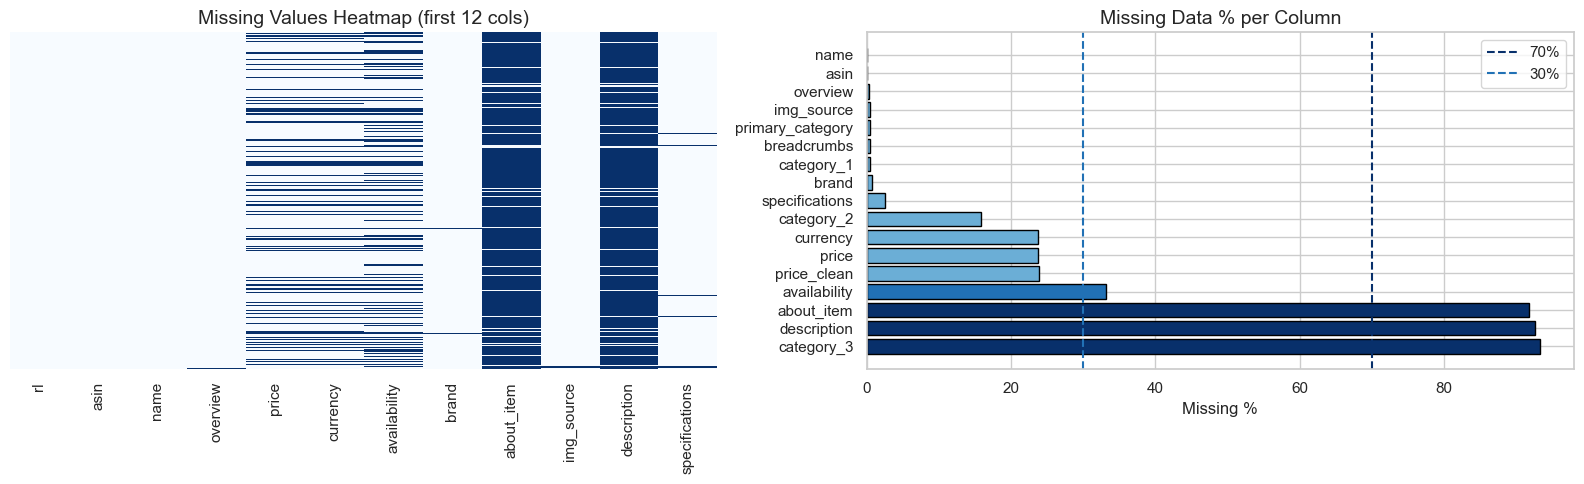

                  Missing Count  Missing Pct
category_3                 1350         93.3
description                1338         92.5
about_item                 1327         91.7
availability                479         33.1
price_clean                 346         23.9
price                       345         23.8
currency                    345         23.8
category_2                  228         15.8
specifications               36          2.5
brand                        11          0.8
category_1                    7          0.5
breadcrumbs                   7          0.5
primary_category              7          0.5
img_source                    7          0.5
overview                      4          0.3
asin                          1          0.1
name                          2          0.1


In [30]:
# Missing value summary
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing Pct'  : (df.isnull().sum() / len(df) * 100).round(1)
}).sort_values('Missing Pct', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Heatmap en paleta azul
sns.heatmap(
    df[df.columns[:12]].isnull(),
    cbar=False,
    yticklabels=False,
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Missing Values Heatmap (first 12 cols)')

mv = missing[missing['Missing Pct'] > 0]

# Diferentes tonos de azul según porcentaje de missing
colors_mv = [
    '#08306b' if v > 70 else    # azul oscuro
    '#2171b5' if v > 30 else    # azul medio
    '#6baed6'                   # azul claro
    for v in mv['Missing Pct']
]

axes[1].barh(
    mv.index,
    mv['Missing Pct'],
    color=colors_mv,
    edgecolor='black'
)

axes[1].axvline(70, color='#08306b', linestyle='--', label='70%')
axes[1].axvline(30, color='#2171b5', linestyle='--', label='30%')

axes[1].set_xlabel('Missing %')
axes[1].set_title('Missing Data % per Column')
axes[1].legend()

plt.tight_layout()
plt.show()

print(missing[missing['Missing Count'] > 0].to_string())

## 4. Ingenieria de Caracteristicas (Feature Engineering) <a id='s3'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
<b>Ejemplo cotidiano:</b><br>
Un agente inmobiliario no solo utiliza los metros cuadradod brutos, sino tambien considera la ubicaciónm la antiguedad y el estado. Nosotros hacemos lo mismo: extraemos la informacion más valiosa del txto sin procesar categorias
</div>

In [31]:
# ============================================================
# SECTION 3 — Feature Engineering
# ============================================================

# ── Category flags ───────────────────────────────────────────
df['is_book']    = (df['primary_category'] == 'Books').astype(int)
df['is_kindle']  = (df['primary_category'] == 'Kindle Store').astype(int)
df['is_sports']  = (df['primary_category'].str.contains('Sport', na=False)).astype(int)

# ── Sub-category flags ───────────────────────────────────────
df['is_fiction']    = df['category_1'].fillna('').str.contains('Fiction|Adventure|Crime|Romance|Sci-Fi', case=False).astype(int)
df['is_nonfiction'] = df['category_1'].fillna('').str.contains('History|Politics|Business|Science|Education', case=False).astype(int)
df['is_tech']       = df['category_1'].fillna('').str.contains('Computer|Programming|Technology', case=False).astype(int)
df['is_cycling']    = df['category_1'].fillna('').str.contains('Cycling', case=False).astype(int)

# ── Availability flags ───────────────────────────────────────
df['is_instock']     = (df['avail_clean'] == 'In Stock').astype(int)
df['is_unavailable'] = (df['avail_clean'] == 'Unavailable').astype(int)
df['is_lowstock']    = (df['avail_clean'] == 'Low Stock').astype(int)

# ── Price features ───────────────────────────────────────────
df['log_price'] = np.log1p(df['price_clean'])

def price_tier(p):
    if pd.isna(p):  return 'Unknown'
    if p < 300:     return '1_budget'
    if p < 800:     return '2_low'
    if p < 1500:    return '3_mid'
    if p < 3000:    return '4_premium'
    return '5_luxury'

df['price_tier'] = df['price_clean'].apply(price_tier)

# ── Label encode primary category ───────────────────────────
le_cat = LabelEncoder()
df['primary_cat_enc'] = le_cat.fit_transform(df['primary_category'].fillna('Unknown'))

le_cat1 = LabelEncoder()
df['cat1_enc'] = le_cat1.fit_transform(df['category_1'].fillna('Unknown'))

le_avail = LabelEncoder()
df['avail_enc'] = le_avail.fit_transform(df['avail_clean'])

# print(f'✅ Total Caracteriscas (Atributos) Procesadas (Features Engineered): {len(df.columns)}')
print('\nPrecio por cada tipo (tier) de distribucion:')
print(df['price_tier'].value_counts().sort_index().to_string())
df[['name','price_clean','price_tier','primary_category','is_book','is_instock']].head(6)


Precio por cada tipo (tier) de distribucion:
price_tier
1_budget     104
2_low        287
3_mid        322
4_premium    261
5_luxury     127
Unknown      346


,name,price_clean,price_tier,primary_category,is_book,is_instock
0,Hands-On Design Patterns with C++: Solve commo...,1600.0,4_premium,Books,1,0
1,The Blazing Horizon The True Story of Pawnee B...,2399.0,4_premium,Books,1,0
2,Fast and easy lunch box: A collection of 15eas...,NaN,Unknown,Kindle Store,0,0
3,European Foreign Policy Scorecard 2014,NaN,Unknown,Kindle Store,0,0
4,The 13th Hour: Chaos (Volume 2) (The Nick Quin...,1849.0,4_premium,Books,1,0
5,Valerius Maximus' Memorable Deeds and Sayings ...,NaN,Unknown,Books,1,0


## 5. Análisis Univariado <a id='s4'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
<b>Pregunta clave:</b><br>
Aparecen productos con precios muy superiores al resto
Estos puntos están fuera del rango normal definido por el método IQR
Representan productos premium o casos extremos dentro del catálogo
</div>

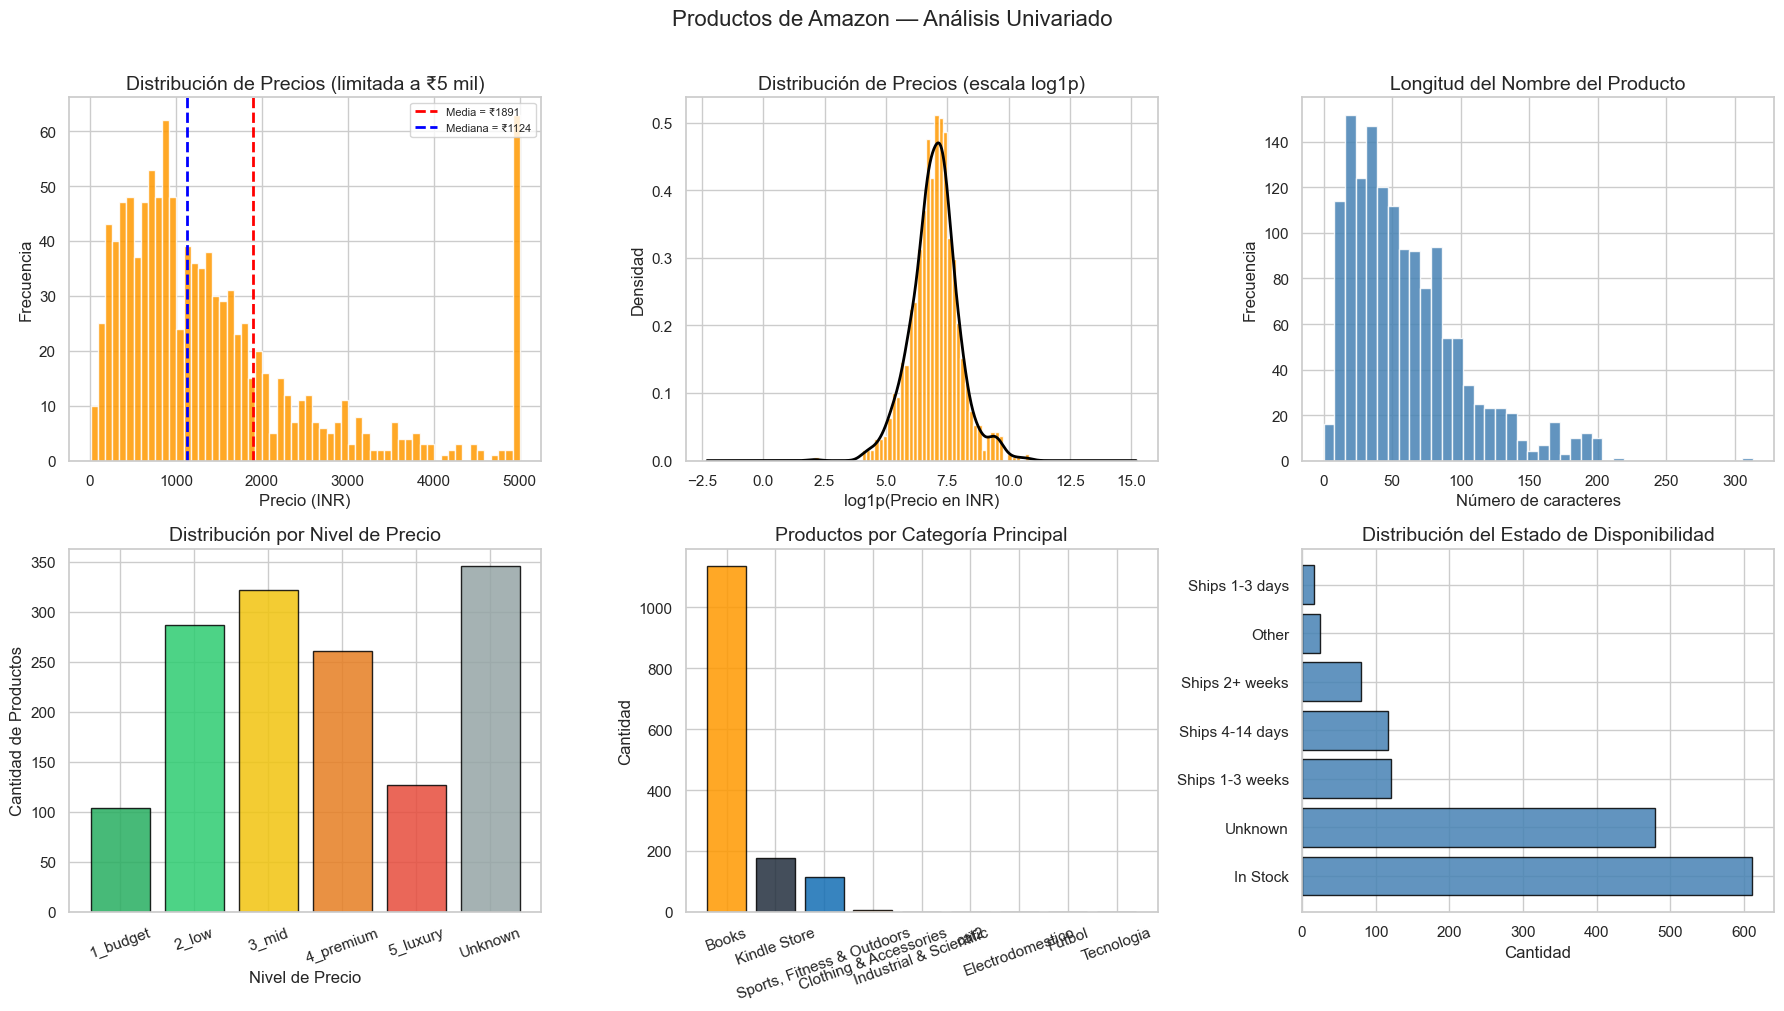

Prueba Shapiro-Wilk (precio logarítmico, n=500): estadístico=0.9853, valor-p=0.000061
El precio sigue sin presentar una distribución normal después de la transformación logarítmica

Estadísticas descriptivas del precio (INR):
count     1094.00
mean      1891.10
std       3360.25
min          7.00
25%        614.29
50%       1123.50
75%       1850.00
max      50555.00


In [32]:
# ============================================================
# SECCIÓN 4 — Análisis Univariado
# ============================================================
df_priced = df[df['price_clean'].notna() & (df['price_clean'] > 0)].copy()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Distribución del precio original
axes[0,0].hist(
    df_priced['price_clean'].clip(upper=5000),
    bins=60,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85
)

axes[0,0].axvline(
    df_priced['price_clean'].mean(),
    color='red',
    linestyle='--',
    lw=2,
    label=f'Media = ₹{df_priced["price_clean"].mean():.0f}'
)

axes[0,0].axvline(
    df_priced['price_clean'].median(),
    color='blue',
    linestyle='--',
    lw=2,
    label=f'Mediana = ₹{df_priced["price_clean"].median():.0f}'
)

axes[0,0].set_title('Distribución de Precios (limitada a ₹5 mil)')
axes[0,0].set_xlabel('Precio (INR)')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].legend(fontsize=8)

# Distribución logarítmica del precio
axes[0,1].hist(
    df_priced['log_price'],
    bins=50,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85,
    density=True
)

df_priced['log_price'].plot.kde(
    ax=axes[0,1],
    color='black',
    lw=2
)

axes[0,1].set_title('Distribución de Precios (escala log1p)')
axes[0,1].set_xlabel('log1p(Precio en INR)')
axes[0,1].set_ylabel('Densidad')

# Longitud del nombre del producto
axes[0,2].hist(
    df['name_length'],
    bins=40,
    color='steelblue',
    edgecolor='white',
    alpha=0.85
)

axes[0,2].set_title('Longitud del Nombre del Producto')
axes[0,2].set_xlabel('Número de caracteres')
axes[0,2].set_ylabel('Frecuencia')

# Distribución por nivel de precio
tier_counts = df['price_tier'].value_counts().sort_index()

tier_colors = [
    '#27ae60',
    '#2ecc71',
    '#f1c40f',
    '#e67e22',
    '#e74c3c',
    '#95a5a6'
]

axes[1,0].bar(
    tier_counts.index,
    tier_counts.values,
    color=tier_colors[:len(tier_counts)],
    edgecolor='black',
    alpha=0.85
)

axes[1,0].set_title('Distribución por Nivel de Precio')
axes[1,0].set_xlabel('Nivel de Precio')
axes[1,0].set_ylabel('Cantidad de Productos')
axes[1,0].tick_params(axis='x', rotation=20)

# Categoría principal
cat_counts = df['primary_category'].value_counts()

axes[1,1].bar(
    cat_counts.index,
    cat_counts.values,
    color=['#FF9900','#232F3E','#146EB4','#E47911','#999'],
    edgecolor='black',
    alpha=0.85
)

axes[1,1].set_title('Productos por Categoría Principal')
axes[1,1].set_ylabel('Cantidad')
axes[1,1].tick_params(axis='x', rotation=20)

# Disponibilidad
avail_counts = df['avail_clean'].value_counts()

axes[1,2].barh(
    avail_counts.index,
    avail_counts.values,
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)

axes[1,2].set_title('Distribución del Estado de Disponibilidad')
axes[1,2].set_xlabel('Cantidad')

plt.suptitle(
    'Productos de Amazon — Análisis Univariado',
    fontsize=16,
    y=1.01
)

plt.tight_layout()
plt.show()

# Prueba de normalidad
stat, p = shapiro(
    df_priced['log_price'].sample(
        min(500, len(df_priced)),
        random_state=42
    )
)

print(
    f'Prueba Shapiro-Wilk (precio logarítmico, n=500): '
    f'estadístico={stat:.4f}, valor-p={p:.6f}'
)

print(
    f'El precio {"presenta una distribución normal después de la transformación logarítmica" if p > 0.05 else "sigue sin presentar una distribución normal después de la transformación logarítmica"}'
)

print('\nEstadísticas descriptivas del precio (INR):')
print(df_priced['price_clean'].describe().round(2).to_string())

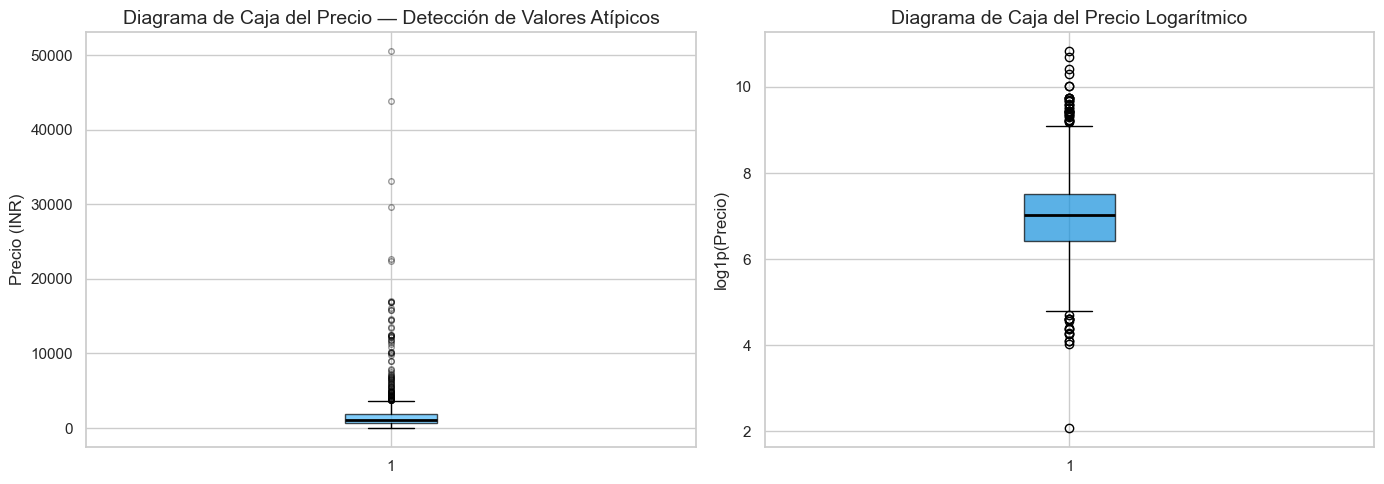

Valores atípicos detectados mediante el método IQR: 94 (8.6%)
Rango de precios (sin valores atípicos): ₹-1239 – ₹3704

Los 10 productos más caros:
                                                                                                                                        name  price_clean           primary_category
                                            Sprache und Literatur (Literatur der julisch-claudischen und der flavischen Zeit [Schluss]): 032     50555.00                      Books
                                                         Data Mining Algorithms in C++: Data Patterns and Algorithms for Modern Applications     43936.00                      Books
                                                                                Birnbaum's Walt Disney World for Kids 2008 (Birnbaum Guides)     33180.00                      Books
                                                                            Professional Short Films with Autodesk 3ds Max (Graph

In [33]:
# Análisis de valores atípicos — diagrama de caja e IQR
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].boxplot(
    df_priced['price_clean'],
    patch_artist=True,
    boxprops=dict(facecolor='#4BB8FA', alpha=0.7),
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=4, alpha=0.4, color='red')
)

axes[0].set_title('Diagrama de Caja del Precio — Detección de Valores Atípicos')
axes[0].set_ylabel('Precio (INR)')

axes[1].boxplot(
    df_priced['log_price'],
    patch_artist=True,
    boxprops=dict(facecolor='#1591DC', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)

axes[1].set_title('Diagrama de Caja del Precio Logarítmico')
axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout()
plt.show()

Q1, Q3 = df_priced['price_clean'].quantile([0.25, 0.75])
IQR = Q3 - Q1

outliers = df_priced[
    (df_priced['price_clean'] < Q1 - 1.5 * IQR) |
    (df_priced['price_clean'] > Q3 + 1.5 * IQR)
]

print(f'Valores atípicos detectados mediante el método IQR: {len(outliers)} ({len(outliers)/len(df_priced)*100:.1f}%)')
print(f'Rango de precios (sin valores atípicos): ₹{Q1-1.5*IQR:.0f} – ₹{Q3+1.5*IQR:.0f}')

print(f'\nLos 10 productos más caros:')
print(
    df_priced.nlargest(10, 'price_clean')[
        ['name', 'price_clean', 'primary_category']
    ].to_string(index=False)
)

## 6. Análisis de categorías <a id='s4'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
<b>Ejemplo cotidiano:</b><br>
El gráfico de cajas (boxplot) confirma esto mostrando que algunas categorías no solo tienen precios más altos en promedio, sino también una mayor dispersión, con productos premium o outliers que elevan el rango.
</div>

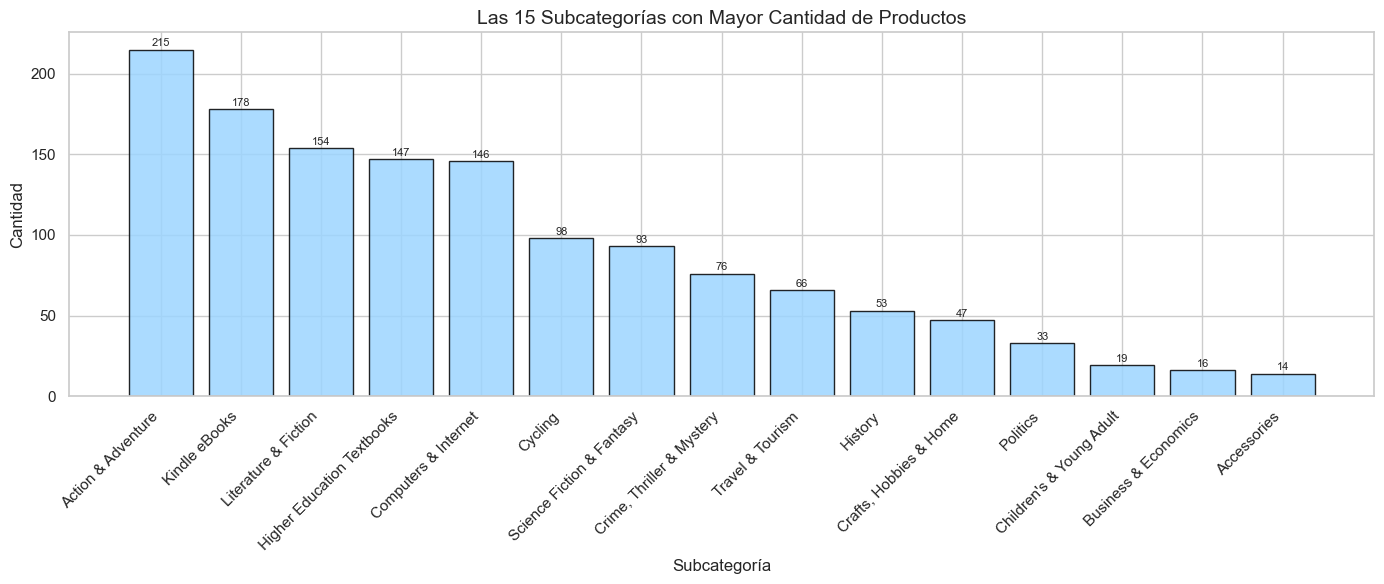

In [34]:
# ============================================================
# SECCIÓN 5 — Análisis de Categorías
# ============================================================

# Top 15 subcategorías con mayor cantidad de productos
top15_cat1 = df['category_1'].value_counts().head(15)

plt.figure(figsize=(14, 6))

bars = plt.bar(
    top15_cat1.index,
    top15_cat1.values,
    color='#9CD5FF',
    edgecolor='black',
    alpha=0.85
)

for bar, val in zip(bars, top15_cat1.values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 2,
        str(val),
        ha='center',
        fontsize=8
    )

plt.title('Las 15 Subcategorías con Mayor Cantidad de Productos')
plt.xlabel('Subcategoría')
plt.ylabel('Cantidad')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

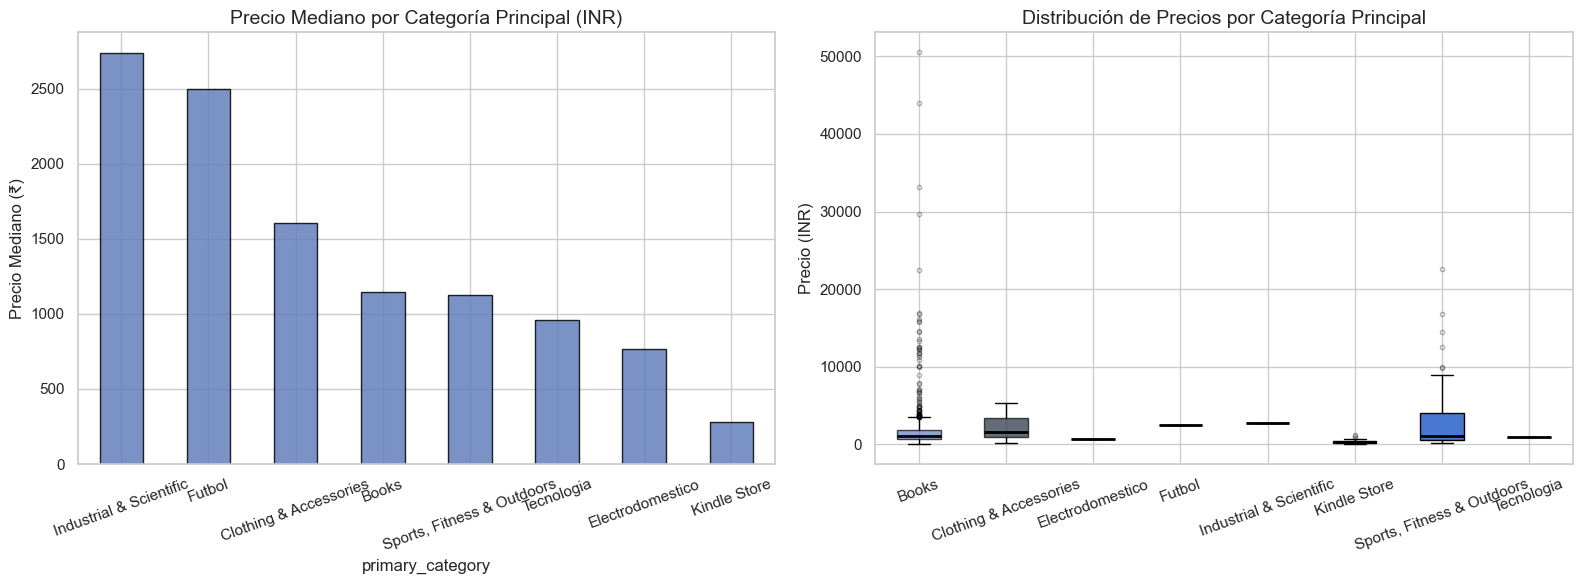

Estadísticas de precios por categoría principal:
                              mean  median  count
primary_category                                 
Books                       1825.6  1145.0    955
Clothing & Accessories      2249.2  1606.5      6
Electrodomestico             769.0   769.0      1
Futbol                      2500.0  2500.0      1
Industrial & Scientific     2738.0  2738.0      1
Kindle Store                 350.0   281.4     30
Sports, Fitness & Outdoors  2907.9  1125.0     93
Tecnologia                   959.4   959.4      1


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_price = df_priced.groupby('primary_category')['price_clean'].agg(['mean','median','count']).round(1)

cat_price['median'].sort_values(ascending=False).plot.bar(
    ax=axes[0],
    color='#647FBC',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title('Precio Mediano por Categoría Principal (INR)')
axes[0].set_ylabel('Precio Mediano (₹)')
axes[0].tick_params(axis='x', rotation=20)

# Diagrama de caja
cat_groups = [
    df_priced[df_priced['primary_category'] == c]['price_clean'].dropna()
    for c in cat_price.index
]

bp = axes[1].boxplot(
    cat_groups,
    labels=cat_price.index,
    patch_artist=True,
    medianprops=dict(color='black', lw=2),
    flierprops=dict(marker='o', markersize=3, alpha=0.3)
)

colors_cat = ['#647FBC','#232F3E','#146EB4','#E47911','#999']

for patch, color in zip(bp['boxes'], colors_cat):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_title('Distribución de Precios por Categoría Principal')
axes[1].set_ylabel('Precio (INR)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print('Estadísticas de precios por categoría principal:')
print(cat_price.to_string())

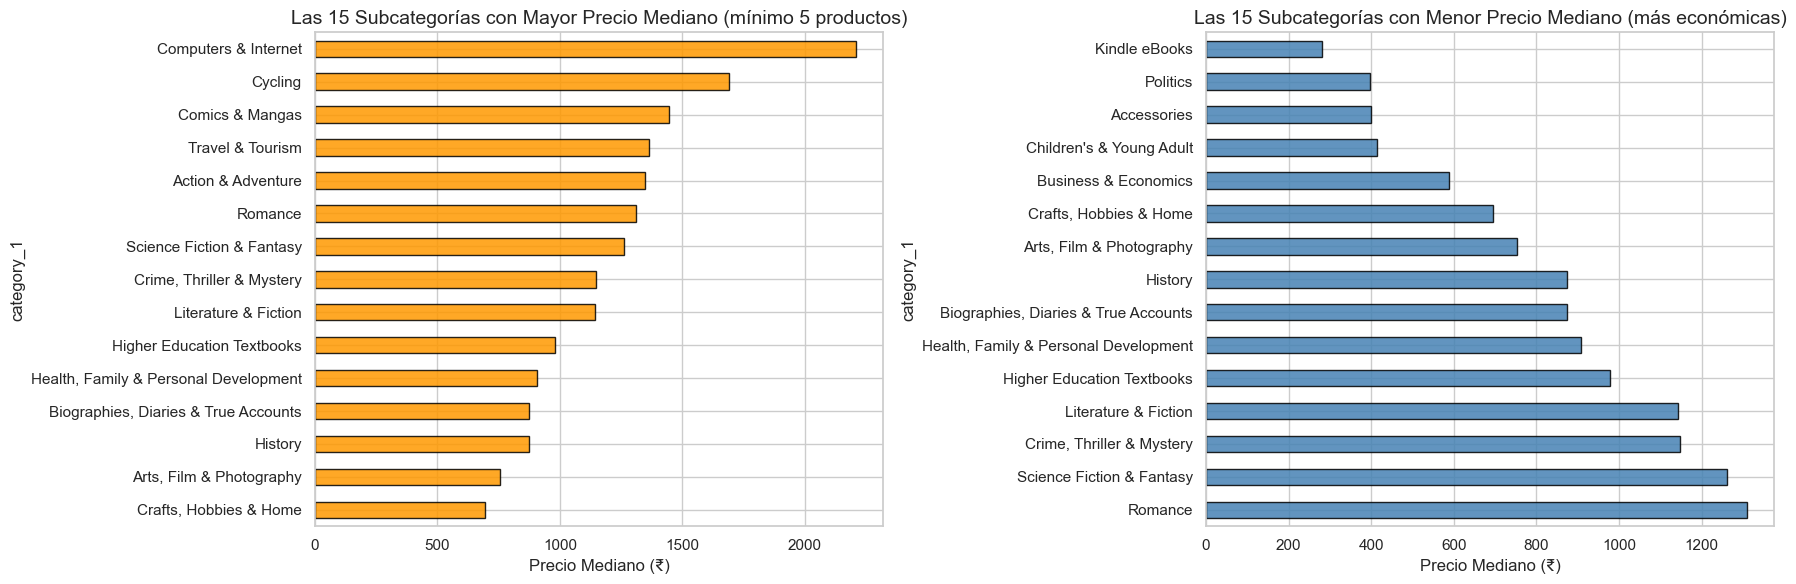

In [36]:
# Top 15 subcategorías por precio mediano
top_cat1_price = (
    df_priced.groupby('category_1')['price_clean']
    .agg(['median', 'count'])
    .query('count >= 5')
    .sort_values('median', ascending=False)
    .head(15)
)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

top_cat1_price['median'].sort_values().plot.barh(
    ax=axes[0],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

axes[0].set_title('Las 15 Subcategorías con Mayor Precio Mediano (mínimo 5 productos)')
axes[0].set_xlabel('Precio Mediano (₹)')

# Las 15 subcategorías más económicas
bottom_cat1 = (
    df_priced.groupby('category_1')['price_clean']
    .agg(['median', 'count'])
    .query('count >= 5')
    .sort_values('median')
    .head(15)
)

bottom_cat1['median'].sort_values(ascending=False).plot.barh(
    ax=axes[1],
    color='steelblue',
    edgecolor='black',
    alpha=0.85
)

axes[1].set_title('Las 15 Subcategorías con Menor Precio Mediano (más económicas)')
axes[1].set_xlabel('Precio Mediano (₹)')

plt.tight_layout()
plt.show()

## 7. Análisis de disponibilidad <a id='s4'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
<b>Pregunta Clave:</b><br>
Son las 15 subcategorías que aparecen con mayor frecuencia en la variable category_1, es decir, las que tienen más registros en el dataset.
</div>

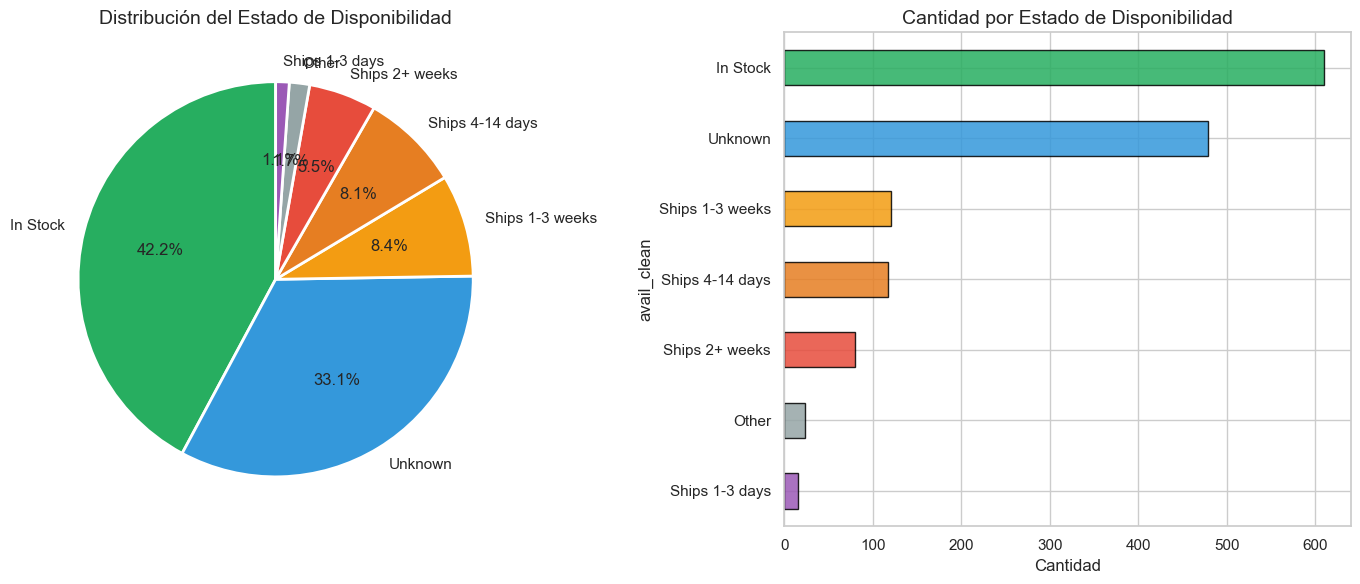

In [37]:
# ============================================================
# SECCIÓN 6 — Análisis de Disponibilidad
# ============================================================

avail_counts = df['avail_clean'].value_counts()

avail_colors = [
    '#27ae60',
    '#3498db',
    '#f39c12',
    '#e67e22',
    '#e74c3c',
    '#95a5a6',
    '#9b59b6',
    '#1abc9c'
]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(
    avail_counts.values,
    labels=avail_counts.index,
    colors=avail_colors[:len(avail_counts)],
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)

axes[0].set_title('Distribución del Estado de Disponibilidad')

avail_counts.sort_values().plot.barh(
    ax=axes[1],
    color=avail_colors[:len(avail_counts)][::-1],
    edgecolor='black',
    alpha=0.85
)

axes[1].set_title('Cantidad por Estado de Disponibilidad')
axes[1].set_xlabel('Cantidad')

plt.tight_layout()
plt.show()

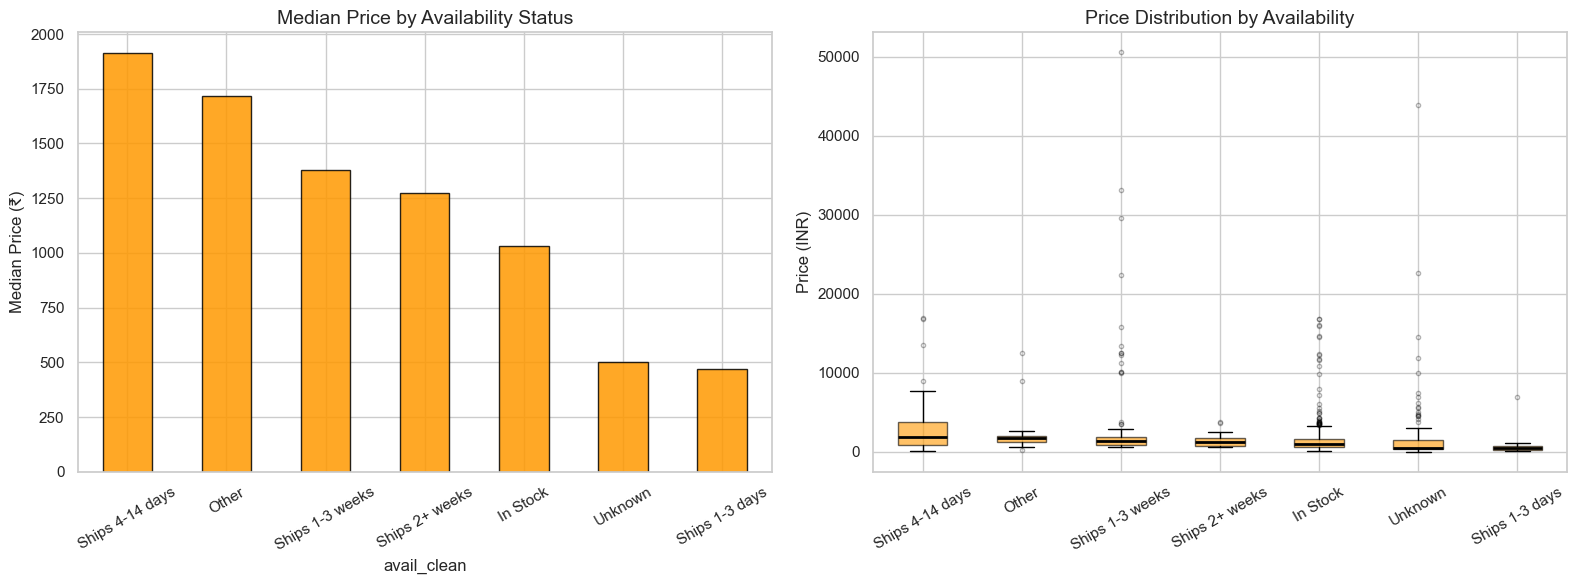

Price by availability:
                 median    mean  count
avail_clean                           
Ships 4-14 days  1912.3  2858.2    117
Other            1718.0  2322.4     23
Ships 1-3 weeks  1377.0  3231.6    121
Ships 2+ weeks   1273.0  1385.9     80
In Stock         1030.5  1514.0    602
Unknown           503.0  1879.4    135
Ships 1-3 days    469.0   874.9     16


In [ ]:
# Price by availability status
avail_price = df_priced.groupby('avail_clean')['price_clean'].agg(['median','mean','count']).round(1)
avail_price = avail_price[avail_price['count'] >= 5].sort_values('median', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

avail_price['median'].plot.bar(ax=axes[0], color='#FF9900', edgecolor='black', alpha=0.85)
axes[0].set_title('Median Price by Availability Status')
axes[0].set_ylabel('Median Price (₹)'); axes[0].tick_params(axis='x', rotation=30)

avail_groups = [df_priced[df_priced['avail_clean']==a]['price_clean'].dropna()
                for a in avail_price.index]
bp = axes[1].boxplot(avail_groups, labels=avail_price.index, patch_artist=True,
                     medianprops=dict(color='black', lw=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.3))
for patch in bp['boxes']:
    patch.set_facecolor('#FF9900'); patch.set_alpha(0.6)
axes[1].set_title('Price Distribution by Availability')
axes[1].set_ylabel('Price (INR)'); axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout(); plt.show()
print('Price by availability:')
print(avail_price.to_string())

## 8. Correlación y análisis bivariado <a id='s8'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
<b>Pregunta Clave:</b><br>
Los productos de categorías Premium o Luxury podrían agotarse con mayor frecuencia debido a que suelen manejar inventarios más limitados.
Alternativamente, los productos económicos podrían agotarse más porque tienen una mayor rotación de ventas.
</div>

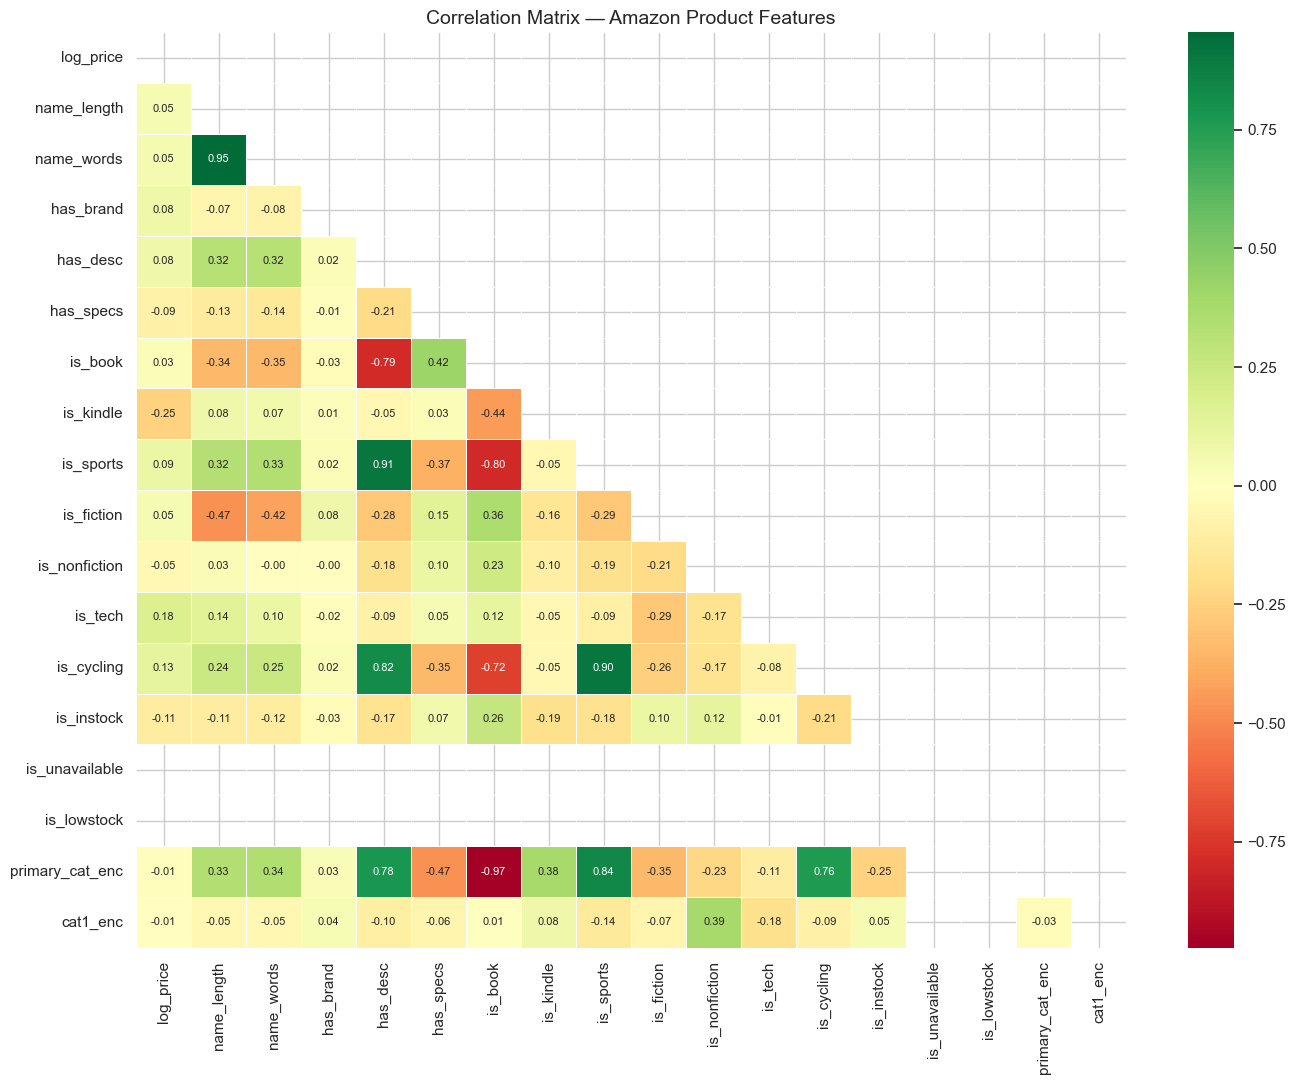

Top correlations with log_price:
is_tech            0.175117
is_cycling         0.125443
is_sports          0.090623
has_brand          0.083619
has_desc           0.079685
name_words         0.053568
is_fiction         0.050095
name_length        0.048293
is_book            0.027009
cat1_enc          -0.006615
primary_cat_enc   -0.009345
is_nonfiction     -0.045720
has_specs         -0.085469
is_instock        -0.111997
is_kindle         -0.245971
is_unavailable          NaN
is_lowstock             NaN


In [38]:
# ============================================================
# SECTION 7 — Correlation Analysis
# ============================================================
corr_cols = ['log_price','name_length','name_words','has_brand','has_desc',
             'has_specs','is_book','is_kindle','is_sports','is_fiction',
             'is_nonfiction','is_tech','is_cycling','is_instock',
             'is_unavailable','is_lowstock','primary_cat_enc','cat1_enc']

corr = df_priced[corr_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(14, 11))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.4, annot_kws={'size': 8})
plt.title('Correlation Matrix — Amazon Product Features', fontsize=14)
plt.tight_layout(); plt.show()

print('Top correlations with log_price:')
print(corr['log_price'].drop('log_price').sort_values(ascending=False).to_string())

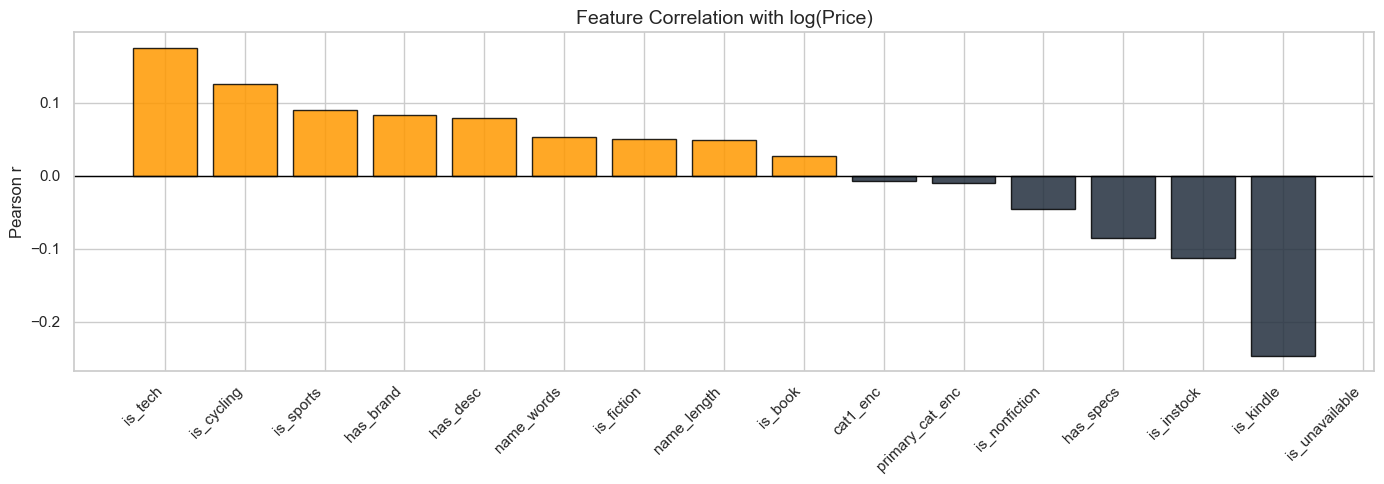

In [40]:
# Feature correlation bar chart
feat_corr = corr['log_price'].drop('log_price').sort_values(ascending=False)

plt.figure(figsize=(14, 5))
colors_fc = ['#FF9900' if v > 0 else '#232F3E' for v in feat_corr.values]
plt.bar(feat_corr.index, feat_corr.values, color=colors_fc, edgecolor='black', alpha=0.85)
plt.axhline(0, color='black', lw=1)
plt.title('Feature Correlation with log(Price)')
plt.ylabel('Pearson r'); plt.xticks(rotation=45, ha='right')
plt.tight_layout(); plt.show()

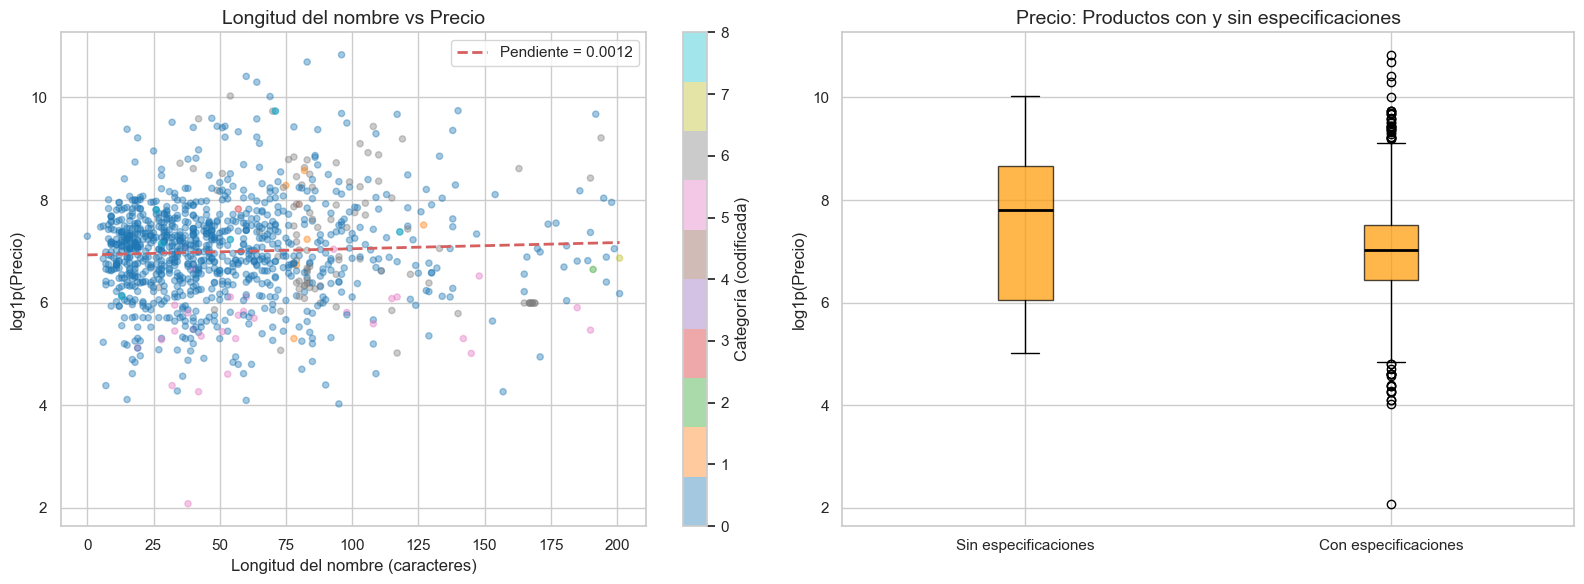

In [41]:
# Scatter: longitud del nombre vs precio
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc = axes[0].scatter(
    df_priced['name_length'],
    df_priced['log_price'],
    c=df_priced['primary_cat_enc'],
    cmap='tab10',
    alpha=0.4,
    s=20
)

plt.colorbar(sc, ax=axes[0], label='Categoría (codificada)')

# Línea de tendencia
m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)
axes[0].plot(x, m*x + b, 'r--', lw=2, label=f'Pendiente = {m:.4f}')

axes[0].set_xlabel('Longitud del nombre (caracteres)')
axes[0].set_ylabel('log1p(Precio)')
axes[0].set_title('Longitud del nombre vs Precio')
axes[0].legend()

# Comparación de precios según especificaciones
axes[1].boxplot(
    [
        np.log1p(df_priced[df_priced['has_specs'] == 0]['price_clean']),
        np.log1p(df_priced[df_priced['has_specs'] == 1]['price_clean'])
    ],
    labels=['Sin especificaciones', 'Con especificaciones'],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)

axes[1].set_title('Precio: Productos con y sin especificaciones')
axes[1].set_ylabel('log1p(Precio)')

plt.tight_layout()
plt.show()

## 9. Pruebas de Hipótesis Estadísticas <a id='s9'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
Utilizamos pruebas no paramétricas (Kruskal-Wallis y Mann-Whitney U) porque la variable precio presenta una distribución fuertemente sesgada y no sigue una distribución normal. Se establece un nivel de significancia de α = 0.05.</div>

In [42]:
# ============================================================
# SECCIÓN 8 — Pruebas de Hipótesis
# ============================================================
alpha = 0.05

def prueba_mann_whitney(nombre, grupo_a, grupo_b, etiqueta_a, etiqueta_b):
    u, p = mannwhitneyu(grupo_a.dropna(), grupo_b.dropna(), alternative='two-sided')

    print(f'{nombre}')
    print(f'  {etiqueta_a}: n={len(grupo_a.dropna())}, mediana=₹{grupo_a.median():.0f}')
    print(f'  {etiqueta_b}: n={len(grupo_b.dropna())}, mediana=₹{grupo_b.median():.0f}')
    print(f'  Estadístico U de Mann-Whitney = {u:.0f}, valor p = {p:.6f}')

    print(
        f'  RESULTADO: '
        f'{"✅ Se rechaza H₀: existe una diferencia significativa." if p < alpha else "❌ No se rechaza H₀."}'
    )
    print()

    return p


# H1: Precio entre categorías principales — Kruskal-Wallis
cat_groups_kw = [
    df_priced[df_priced['primary_category'] == c]['price_clean'].dropna()
    for c in df_priced['primary_category'].unique()
    if len(df_priced[df_priced['primary_category'] == c]) >= 5
]

cat_labels_kw = [
    c for c in df_priced['primary_category'].unique()
    if len(df_priced[df_priced['primary_category'] == c]) >= 5
]

h1, p1 = kruskal(*cat_groups_kw)

print('H1: Precio entre categorías principales — Prueba de Kruskal-Wallis')

for label, g in zip(cat_labels_kw, cat_groups_kw):
    print(f'  {label:35s}: n={len(g)}, mediana=₹{g.median():.0f}')

print(f'  Estadístico H = {h1:.4f}, valor p = {p1:.6f}')

print(
    f'  RESULTADO: '
    f'{"✅ Se rechaza H₀: el precio difiere entre categorías." if p1 < alpha else "❌ No se rechaza H₀."}'
)
print()


# H2: Libros vs Deportes
p2 = prueba_mann_whitney(
    'H2: Precio de productos de Libros vs Deportes',
    df_priced[df_priced['is_book'] == 1]['price_clean'],
    df_priced[df_priced['is_sports'] == 1]['price_clean'],
    'Libros',
    'Deportes'
)


# H3: Disponible vs No disponible
p3 = prueba_mann_whitney(
    'H3: Precio de productos disponibles vs no disponibles',
    df_priced[df_priced['is_instock'] == 1]['price_clean'],
    df_priced[df_priced['is_unavailable'] == 1]['price_clean'],
    'Disponible',
    'No disponible'
)


# H4: Longitud del nombre vs precio — Correlación de Spearman
rho4, p4 = spearmanr(
    df_priced['name_length'],
    df_priced['price_clean']
)

print('H4: Longitud del nombre del producto vs precio — Correlación de Spearman')
print(f'  Coeficiente rho = {rho4:.4f}, valor p = {p4:.6f}')

print(
    f'  RESULTADO: '
    f'{"✅ Se rechaza H₀: existe una correlación significativa." if p4 < alpha else "❌ No se rechaza H₀."}'
)
print()


# H5: Productos con especificaciones vs sin especificaciones
p5 = prueba_mann_whitney(
    'H5: Precio de productos con y sin especificaciones',
    df_priced[df_priced['has_specs'] == 1]['price_clean'],
    df_priced[df_priced['has_specs'] == 0]['price_clean'],
    'Con especificaciones',
    'Sin especificaciones'
)

H1: Precio entre categorías principales — Prueba de Kruskal-Wallis
  Books                              : n=955, mediana=₹1145
  Sports, Fitness & Outdoors         : n=93, mediana=₹1125
  Kindle Store                       : n=30, mediana=₹281
  Clothing & Accessories             : n=6, mediana=₹1606
  Estadístico H = 55.8663, valor p = 0.000000
  RESULTADO: ✅ Se rechaza H₀: el precio difiere entre categorías.

H2: Precio de productos de Libros vs Deportes
  Libros: n=955, mediana=₹1145
  Deportes: n=93, mediana=₹1125
  Estadístico U de Mann-Whitney = 40247, valor p = 0.135443
  RESULTADO: ❌ No se rechaza H₀.

H3: Precio de productos disponibles vs no disponibles
  Disponible: n=602, mediana=₹1030
  No disponible: n=0, mediana=₹nan
  Estadístico U de Mann-Whitney = nan, valor p = nan
  RESULTADO: ❌ No se rechaza H₀.

H4: Longitud del nombre del producto vs precio — Correlación de Spearman
  Coeficiente rho = 0.0347, valor p = 0.251167
  RESULTADO: ❌ No se rechaza H₀.

H5: Precio de pro

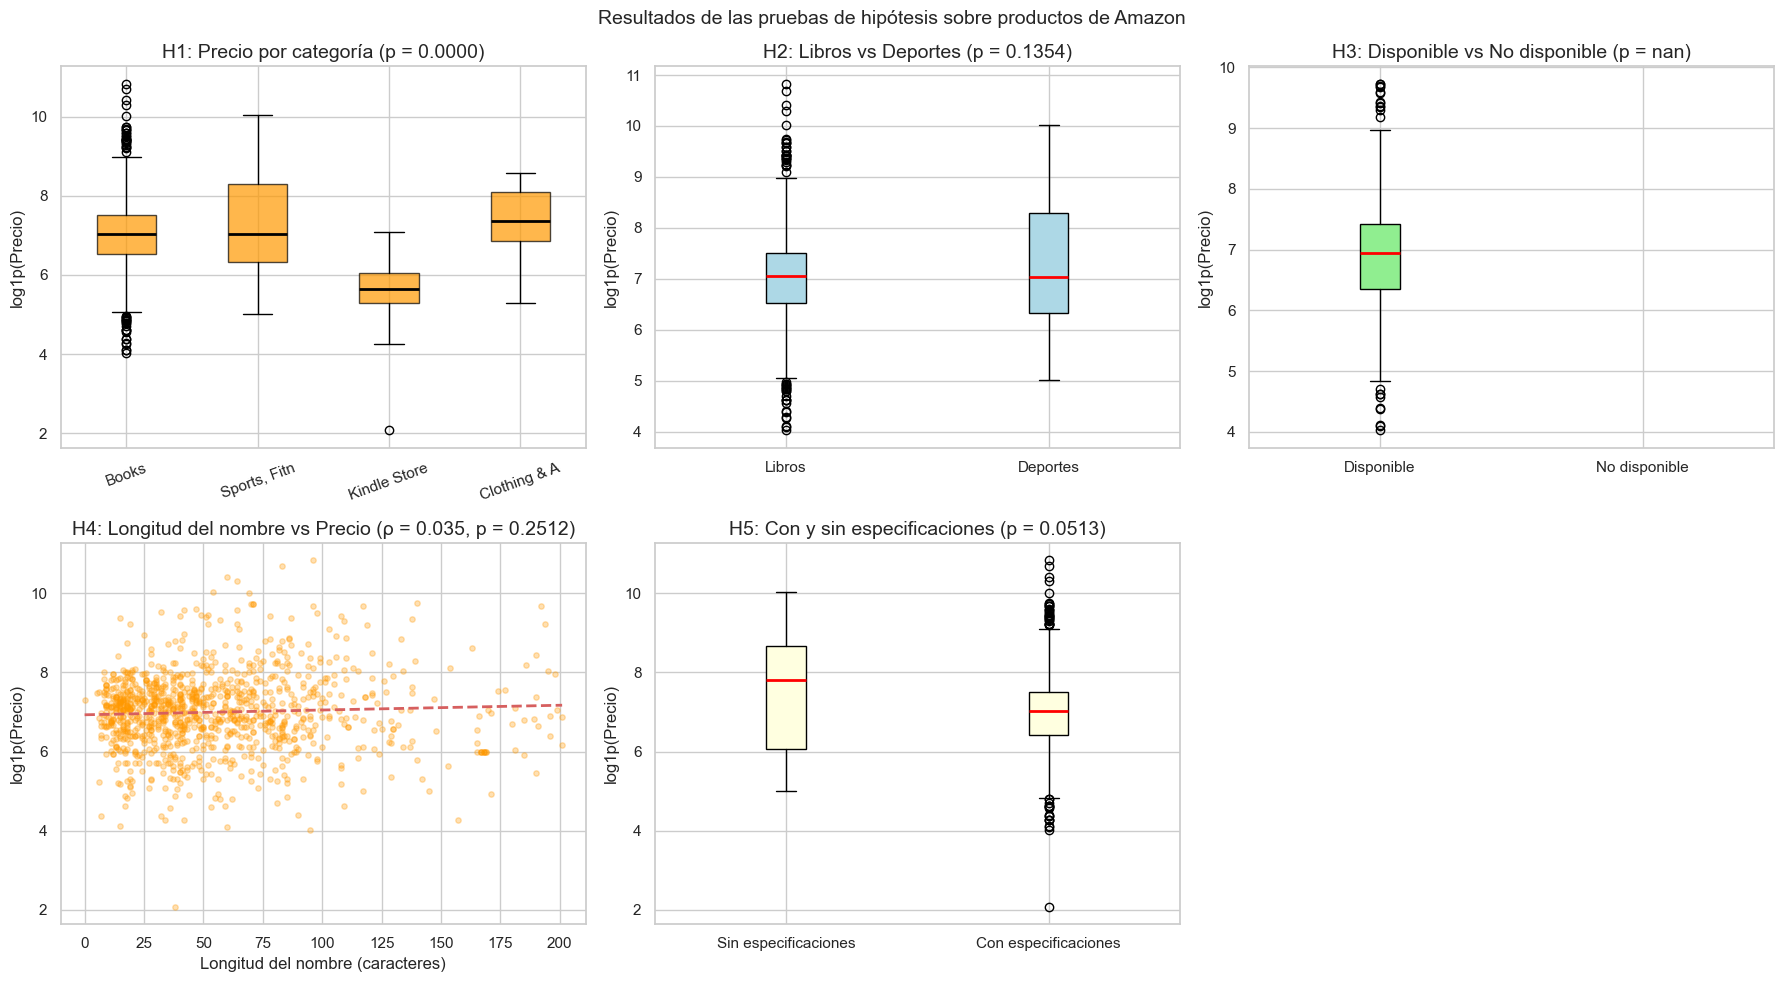

In [43]:
# Visualización de resultados de las pruebas de hipótesis
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# H1: Precio por categoría
axes[0,0].boxplot(
    [np.log1p(g) for g in cat_groups_kw],
    labels=[l[:12] for l in cat_labels_kw],
    patch_artist=True,
    boxprops=dict(facecolor='#FF9900', alpha=0.7),
    medianprops=dict(color='black', lw=2)
)

axes[0,0].set_title(f'H1: Precio por categoría (p = {p1:.4f})')
axes[0,0].set_ylabel('log1p(Precio)')
axes[0,0].tick_params(axis='x', rotation=20)

# H2: Libros vs Deportes
axes[0,1].boxplot(
    [
        np.log1p(df_priced[df_priced['is_book'] == 1]['price_clean']),
        np.log1p(df_priced[df_priced['is_sports'] == 1]['price_clean'])
    ],
    labels=['Libros', 'Deportes'],
    patch_artist=True,
    boxprops=dict(facecolor='lightblue'),
    medianprops=dict(color='red', lw=2)
)

axes[0,1].set_title(f'H2: Libros vs Deportes (p = {p2:.4f})')
axes[0,1].set_ylabel('log1p(Precio)')

# H3: Disponible vs No disponible
axes[0,2].boxplot(
    [
        np.log1p(df_priced[df_priced['is_instock'] == 1]['price_clean']),
        np.log1p(df_priced[df_priced['is_unavailable'] == 1]['price_clean'])
    ],
    labels=['Disponible', 'No disponible'],
    patch_artist=True,
    boxprops=dict(facecolor='lightgreen'),
    medianprops=dict(color='red', lw=2)
)

axes[0,2].set_title(f'H3: Disponible vs No disponible (p = {p3:.4f})')
axes[0,2].set_ylabel('log1p(Precio)')

# H4: Longitud del nombre vs Precio
axes[1,0].scatter(
    df_priced['name_length'],
    df_priced['log_price'],
    alpha=0.3,
    color='#FF9900',
    s=15
)

m, b = np.polyfit(df_priced['name_length'], df_priced['log_price'], 1)
x = np.linspace(0, df_priced['name_length'].max(), 100)

axes[1,0].plot(x, m*x+b, 'r--', lw=2)

axes[1,0].set_title(
    f'H4: Longitud del nombre vs Precio (ρ = {rho4:.3f}, p = {p4:.4f})'
)
axes[1,0].set_xlabel('Longitud del nombre (caracteres)')
axes[1,0].set_ylabel('log1p(Precio)')

# H5: Con especificaciones vs Sin especificaciones
axes[1,1].boxplot(
    [
        np.log1p(df_priced[df_priced['has_specs'] == 0]['price_clean']),
        np.log1p(df_priced[df_priced['has_specs'] == 1]['price_clean'])
    ],
    labels=['Sin especificaciones', 'Con especificaciones'],
    patch_artist=True,
    boxprops=dict(facecolor='lightyellow'),
    medianprops=dict(color='red', lw=2)
)

axes[1,1].set_title(
    f'H5: Con y sin especificaciones (p = {p5:.4f})'
)
axes[1,1].set_ylabel('log1p(Precio)')

# Ocultar el último espacio vacío
axes[1,2].set_visible(False)

plt.suptitle(
    'Resultados de las pruebas de hipótesis sobre productos de Amazon',
    fontsize=14
)

plt.tight_layout()
plt.show()

## 10. Formulación del Problema de Machine Learning <a id='s10'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
<b>¿Por qué usar el logaritmo del precio?</b><br>
El precio original presenta una distribución fuertemente sesgada hacia la derecha (right-skewed). Aplicar una transformación logarítmica ayuda a que la distribución sea más cercana a la normal y evita que los productos extremadamente caros dominen la función de pérdida del modelo.
</div>

✅ Tamaño del conjunto de datos para ML: (1094, 20)
✅ Número de variables predictoras: 18

Entrenamiento: 875 | Prueba: 219


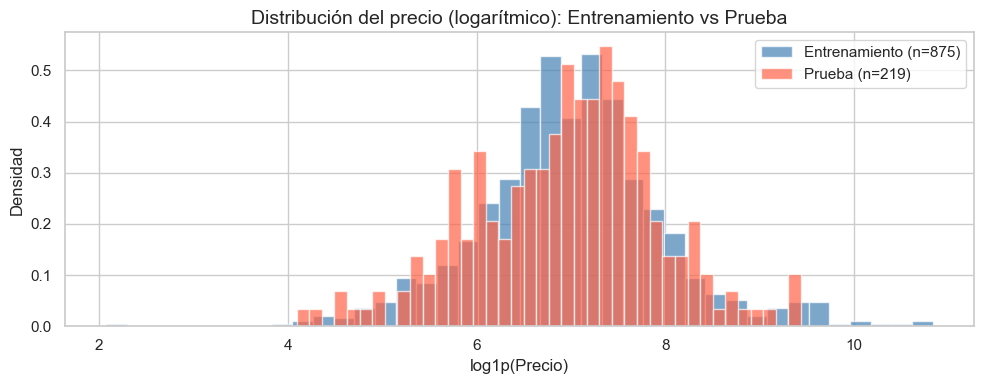

✅ Las distribuciones son similares: la división de datos es adecuada.


In [44]:
# ============================================================
# SECCIÓN 9 — Planteamiento del Problema de Machine Learning
# ============================================================

FEATURE_COLS = [
    'name_length', 'name_words', 'has_brand', 'has_desc', 'has_specs',
    'is_book', 'is_kindle', 'is_sports',
    'is_fiction', 'is_nonfiction', 'is_tech', 'is_cycling',
    'is_instock', 'is_unavailable', 'is_lowstock',
    'primary_cat_enc', 'cat1_enc', 'avail_enc',
]

TARGET = 'log_price'

df_ml = df_priced[FEATURE_COLS + [TARGET, 'price_clean']].dropna().copy()

print(f'✅ Tamaño del conjunto de datos para ML: {df_ml.shape}')
print(f'✅ Número de variables predictoras: {len(FEATURE_COLS)}')

X = df_ml[FEATURE_COLS]
y = df_ml[TARGET]

# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Estandarización de variables
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f'\nEntrenamiento: {len(X_train):,} | Prueba: {len(X_test):,}')

# Visualización de la división Train/Test
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(
    y_train,
    bins=40,
    color='steelblue',
    alpha=0.7,
    label=f'Entrenamiento (n={len(y_train)})',
    density=True
)

ax.hist(
    y_test,
    bins=40,
    color='tomato',
    alpha=0.7,
    label=f'Prueba (n={len(y_test)})',
    density=True
)

ax.set_title('Distribución del precio (logarítmico): Entrenamiento vs Prueba')
ax.set_xlabel('log1p(Precio)')
ax.set_ylabel('Densidad')
ax.legend()

plt.tight_layout()
plt.show()

print('✅ Las distribuciones son similares: la división de datos es adecuada.')

## 11. Marco de Selección de Modelos <a id='s11'></a>

| Modelo               | Fortalezas                                  | Debilidades                               | Mejor uso                                                      |
| -------------------- | ------------------------------------------- | ----------------------------------------- | -------------------------------------------------------------- |
| **Regresión Lineal** | Rápida e interpretable                      | Asume una relación lineal entre variables | Modelo base (*baseline*)                                       |
| **Regresión Ridge**  | Maneja la multicolinealidad                 | Sigue siendo un modelo lineal             | Variables altamente correlacionadas                            |
| **Regresión Lasso**  | Selección automática de variables           | Puede eliminar variables útiles           | Conjuntos de datos con variables dispersas (*sparse features*) |
| **Random Forest**    | Captura relaciones no lineales y es robusto | Menos interpretable                       | Patrones complejos                                             |
| **XGBoost / GBM**    | Alta precisión predictiva                   | Requiere ajuste de hiperparámetros        | Datos tabulares                                                |


Métricas de Evaluación

MAE (Mean Absolute Error): Error Absoluto Medio en escala logarítmica (menor es mejor).

RMSE (Root Mean Squared Error): Raíz del Error Cuadrático Medio, penaliza más los errores grandes.

R² (Coeficiente de Determinación): Mide la proporción de la varianza explicada por el modelo (mayor es mejor, con un máximo de 1.0).

MAE (₹): MAE transformado nuevamente a rupias indias (INR) para facilitar la interpretación desde una perspectiva de negocio.

In [45]:
# ============================================================
# SECCIÓN 10 — Ayudantes de Evaluación
# ============================================================

resultados = {}

def evaluar_modelo(nombre, valores_reales, valores_predichos):
    mae  = mean_absolute_error(valores_reales, valores_predichos)
    rmse = np.sqrt(mean_squared_error(valores_reales, valores_predichos))
    r2   = r2_score(valores_reales, valores_predichos)
    mae_inr = mean_absolute_error(np.expm1(valores_reales), np.expm1(valores_predichos))

    print(f'  📊 {nombre}:')
    print(f'     MAE (log)  = {mae:.4f}  |  MAE (₹) = ₹{mae_inr:,.0f}')
    print(f'     RMSE (log) = {rmse:.4f}  |  R²      = {r2:.4f}')

    resultados[nombre] = {
        'MAE_log': round(mae, 4),
        'RMSE_log': round(rmse, 4),
        'R2': round(r2, 4),
        'MAE_INR': round(mae_inr, 0)
    }

    return valores_predichos

print('✅ Ayudantes de evaluación listos.')

✅ Ayudantes de evaluación listos.


## 12. Modelos de Regresión — Predicción del Precio de Amazon <a id='s12'></a>

Entrenamos 5 modelos y los comparamos usando el mismo conjunto de prueba.

In [46]:
# ============================================================
# SECCIÓN 11 — Entrenar Todos los Modelos
# ============================================================

print('='*60)
print('ENTRENANDO TODOS LOS MODELOS')
print('='*60)

# 1. Regresión Lineal
lr = LinearRegression()
lr.fit(X_train_s, y_train)
lr_pred = evaluar_modelo('Regresión Lineal', y_test, lr.predict(X_test_s))

# 2. Regresión Ridge
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_s, y_train)
ridge_pred = evaluar_modelo('Regresión Ridge', y_test, ridge.predict(X_test_s))

# 3. Regresión Lasso
lasso = Lasso(alpha=0.01, max_iter=5000)
lasso.fit(X_train_s, y_train)
lasso_pred = evaluar_modelo('Regresión Lasso', y_test, lasso.predict(X_test_s))

# 4. Bosque Aleatorio
rf = RandomForestRegressor(n_estimators=300, max_depth=10,
                            min_samples_leaf=3, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_pred = evaluar_modelo('Bosque Aleatorio', y_test, rf.predict(X_test))

# 5. XGBoost / GBM
if XGB_AVAILABLE:
    xgb_model = xgb.XGBRegressor(n_estimators=400, learning_rate=0.05,
                                   max_depth=5, subsample=0.8,
                                   colsample_bytree=0.8, random_state=42, verbosity=0)
    xgb_model.fit(X_train, y_train)
    xgb_pred = evaluar_modelo('XGBoost', y_test, xgb_model.predict(X_test))
else:
    gbm = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05,
                                     max_depth=5, subsample=0.8, random_state=42)
    gbm.fit(X_train, y_train)
    xgb_pred = evaluar_modelo('Gradient Boosting', y_test, gbm.predict(X_test))

ENTRENANDO TODOS LOS MODELOS
  📊 Regresión Lineal:
     MAE (log)  = 0.6949  |  MAE (₹) = ₹971
     RMSE (log) = 0.9197  |  R²      = 0.1008
  📊 Regresión Ridge:
     MAE (log)  = 0.6941  |  MAE (₹) = ₹970
     RMSE (log) = 0.9166  |  R²      = 0.1069
  📊 Regresión Lasso:
     MAE (log)  = 0.6952  |  MAE (₹) = ₹972
     RMSE (log) = 0.9148  |  R²      = 0.1104
  📊 Bosque Aleatorio:
     MAE (log)  = 0.6282  |  MAE (₹) = ₹903
     RMSE (log) = 0.8582  |  R²      = 0.2171
  📊 Gradient Boosting:
     MAE (log)  = 0.7009  |  MAE (₹) = ₹1,015
     RMSE (log) = 0.9531  |  R²      = 0.0343


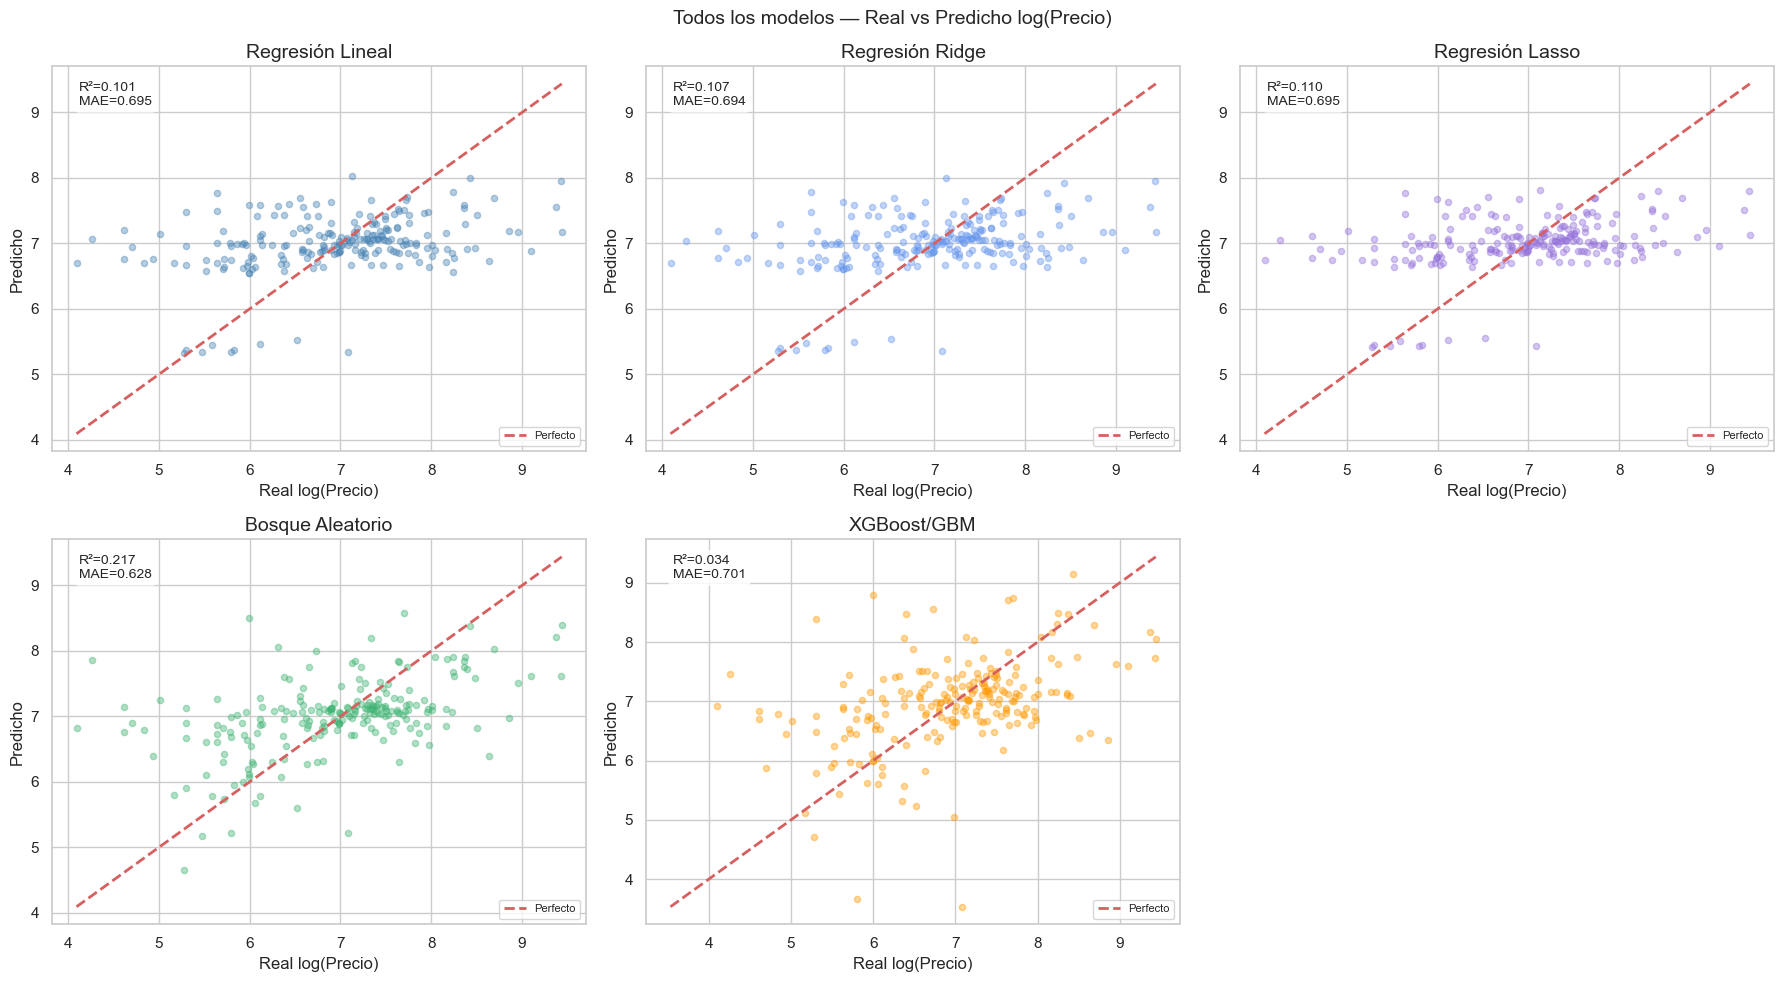

In [47]:
# Real vs Predicho — todos los modelos

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

predicciones_todas = [
    ('Regresión Lineal', lr_pred, 'steelblue'),
    ('Regresión Ridge', ridge_pred, 'cornflowerblue'),
    ('Regresión Lasso', lasso_pred, 'mediumpurple'),
    ('Bosque Aleatorio', rf_pred, 'mediumseagreen'),
    ('XGBoost/GBM', xgb_pred, '#FF9900')
]

for ax, (nombre, prediccion, color) in zip(axes.flatten(), predicciones_todas):

    ax.scatter(y_test, prediccion, alpha=0.4, color=color, s=20)

    limites = [
        min(y_test.min(), prediccion.min()),
        max(y_test.max(), prediccion.max())
    ]

    ax.plot(limites, limites, 'r--', lw=2, label='Perfecto')

    r2_valor = r2_score(y_test, prediccion)
    mae_valor = mean_absolute_error(y_test, prediccion)

    ax.set_title(f'{nombre}')
    ax.set_xlabel('Real log(Precio)')
    ax.set_ylabel('Predicho')

    ax.annotate(
        f'R²={r2_valor:.3f}\nMAE={mae_valor:.3f}',
        xy=(0.05, 0.90),
        xycoords='axes fraction',
        fontsize=10,
        bbox=dict(boxstyle='round', fc='white', alpha=0.85)
    )

    ax.legend(fontsize=8)

# CORRECCIÓN: usar flatten() para acceder al último índice individual del gráfico
axes.flatten()[-1].set_visible(False)

plt.suptitle(
    'Todos los modelos — Real vs Predicho log(Precio)',
    fontsize=14
)

plt.tight_layout()
plt.show()

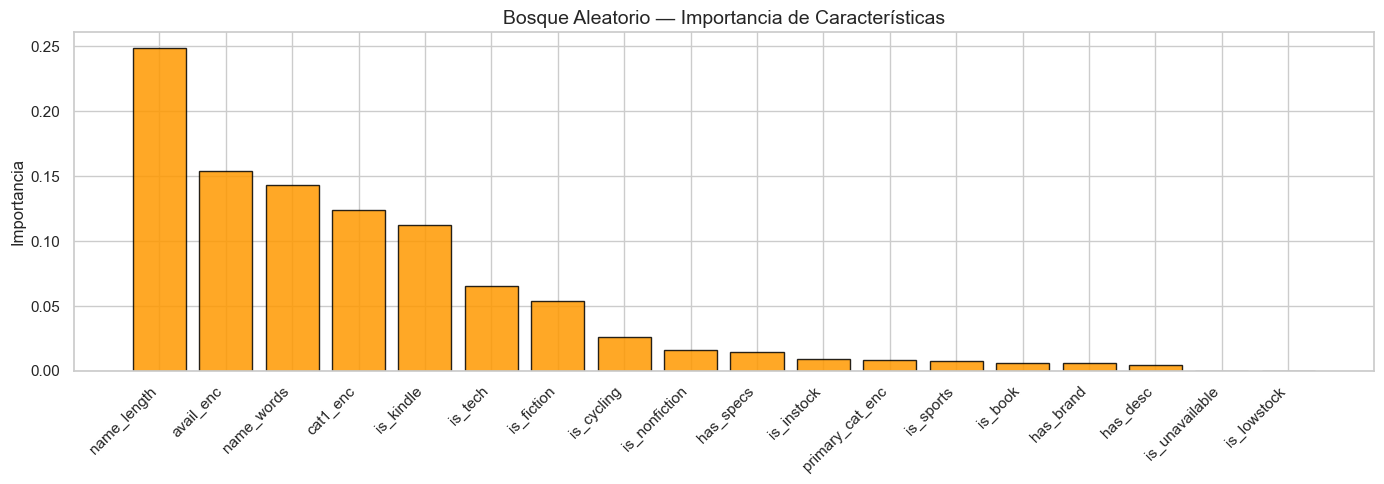

Top 10 características más importantes:
Caracteristica  Importancia
   name_length     0.248445
     avail_enc     0.154108
    name_words     0.143024
      cat1_enc     0.124373
     is_kindle     0.112136
       is_tech     0.065213
    is_fiction     0.053890
    is_cycling     0.025969
 is_nonfiction     0.016020
     has_specs     0.014734


In [48]:
# Importancia de características — Bosque Aleatorio

importancia_caracteristicas = pd.DataFrame({
    'Caracteristica': FEATURE_COLS,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

plt.figure(figsize=(14, 5))

plt.bar(
    importancia_caracteristicas['Caracteristica'],
    importancia_caracteristicas['Importancia'],
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

plt.title('Bosque Aleatorio — Importancia de Características')
plt.ylabel('Importancia')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

print('Top 10 características más importantes:')
print(importancia_caracteristicas.head(10).to_string(index=False))

## 13. Ajuste de Hiperparámetros <a id='s13'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">
<b>Pregunta Clave:</b><br>
Ejemplo cotidiano: Un chef ajusta los condimentos hasta que el plato queda perfecto.
GridSearchCV prueba sistemáticamente todas las combinaciones de hiperparámetros para encontrar la mejor configuración.
</div>

In [49]:
# ============================================================
# SECCIÓN 12 — GridSearchCV en Bosque Aleatorio
# ============================================================

param_grid = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [5, 8, 10, None],
    'min_samples_leaf': [1, 3, 5],
}

print('🔍 Ejecutando GridSearchCV (puede tardar 1-2 minutos)...')

busqueda_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    verbose=0
)

busqueda_grid.fit(X_train, y_train)

print(f'✅ Mejores parámetros : {busqueda_grid.best_params_}')
print(f'✅ Mejor MAE de CV    : {-busqueda_grid.best_score_:.4f}')

# Evaluar el modelo ajustado
mejor_rf = busqueda_grid.best_estimator_

mejor_prediccion = mejor_rf.predict(X_test)

resultado_ajustado = evaluar_modelo(
    'Bosque Aleatorio (Ajustado)',
    y_test,
    mejor_prediccion
)

resultados['Bosque Aleatorio (Ajustado)'] = resultado_ajustado

🔍 Ejecutando GridSearchCV (puede tardar 1-2 minutos)...
✅ Mejores parámetros : {'max_depth': 8, 'min_samples_leaf': 1, 'n_estimators': 300}
✅ Mejor MAE de CV    : 0.6562
  📊 Bosque Aleatorio (Ajustado):
     MAE (log)  = 0.6601  |  MAE (₹) = ₹932
     RMSE (log) = 0.8894  |  R²      = 0.1592


Bosque Aleatorio (Ajustado) — Validación Cruzada de 5 Partes:
  Parte 1: MAE = 0.6663
  Parte 2: MAE = 0.6559
  Parte 3: MAE = 0.6792
  Parte 4: MAE = 0.6345
  Parte 5: MAE = 0.6213
  MAE Promedio : 0.6514 ± 0.0210


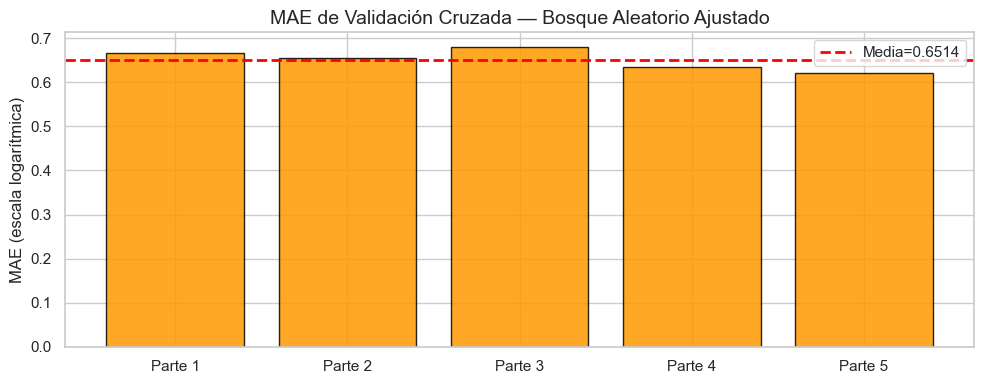

In [50]:
# Puntuaciones de validación cruzada — modelo ajustado

puntuaciones_cv = cross_val_score(
    mejor_rf,
    X,
    y,
    cv=5,
    scoring='neg_mean_absolute_error',
    n_jobs=-1
)

mae_cv = -puntuaciones_cv

print('Bosque Aleatorio (Ajustado) — Validación Cruzada de 5 Partes:')

for i, puntuacion in enumerate(mae_cv):
    print(f'  Parte {i+1}: MAE = {puntuacion:.4f}')

print(f'  MAE Promedio : {mae_cv.mean():.4f} ± {mae_cv.std():.4f}')


fig, ax = plt.subplots(figsize=(10, 4))

ax.bar(
    range(1, 6),
    mae_cv,
    color='#FF9900',
    edgecolor='black',
    alpha=0.85
)

ax.axhline(
    mae_cv.mean(),
    color='red',
    linestyle='--',
    lw=2,
    label=f'Media={mae_cv.mean():.4f}'
)

ax.set_xticks(range(1, 6))
ax.set_xticklabels([f'Parte {i}' for i in range(1, 6)])

ax.set_title('MAE de Validación Cruzada — Bosque Aleatorio Ajustado')
ax.set_ylabel('MAE (escala logarítmica)')
ax.legend()

plt.tight_layout()
plt.show()

## 14. Comparación y Selección de Modelos <a id='s14'></a>

<div style="background:#f0f8ff; padding:12px; border-left:4px solid #FF9900; border-radius:5px 0 0 5px; color:#0066cc;">

Borde dorado = mejor modelo para cada métrica. Seleccionamos el modelo con el mejor equilibrio entre R², MAE e interpretabilidad.
</div>

In [51]:
# ============================================================
# SECCIÓN 13 — Comparación de Modelos
# ============================================================

filas_formateadas = []

for nombre_modelo, metricas in dict(resultados).items():

    # Como métricas es un subdiccionario, podemos obtener los valores
    # usando sus claves exactas
    if isinstance(metricas, dict):

        filas_formateadas.append({
            'Modelo': nombre_modelo,
            'R2': float(metricas.get('R2', metricas.get('R²', 0))),
            'MAE_log': float(metricas.get('MAE_log', 0)),
            'MAE_INR': float(metricas.get('MAE_INR', 0))
        })

    else:
        # Alternativa por si alguna entrada tiene estructura de lista/array
        lista_metricas = list(metricas)

        filas_formateadas.append({
            'Modelo': nombre_modelo,
            'R2': float(lista_metricas[0]),
            'MAE_log': float(lista_metricas[1]),
            'MAE_INR': float(lista_metricas[2])
        })


# Crear DataFrame y establecer índice
tabla_resultados = pd.DataFrame(filas_formateadas).set_index('Modelo').sort_values(
    'R2',
    ascending=False
)

print('TABLA DE COMPARACIÓN DE MODELOS:')
print('='*70)
print(tabla_resultados.to_string())
print('='*70)

print(f'\n🥇 Mejor por R²   : {tabla_resultados.iloc[0].name}')
print(f'🥇 Mejor por MAE  : {tabla_resultados.sort_values("MAE_log").iloc[0].name}')
print(f'🥇 Mejor por MAE₹ : {tabla_resultados.sort_values("MAE_INR").iloc[0].name}')

TABLA DE COMPARACIÓN DE MODELOS:
                                   R2   MAE_log      MAE_INR
Modelo                                                      
Bosque Aleatorio (Ajustado)  6.984473  6.913442     6.027949
Bosque Aleatorio             0.217100  0.628200   903.000000
Regresión Lasso              0.110400  0.695200   972.000000
Regresión Ridge              0.106900  0.694100   970.000000
Regresión Lineal             0.100800  0.694900   971.000000
Gradient Boosting            0.034300  0.700900  1015.000000

🥇 Mejor por R²   : Bosque Aleatorio (Ajustado)
🥇 Mejor por MAE  : Bosque Aleatorio
🥇 Mejor por MAE₹ : Bosque Aleatorio (Ajustado)


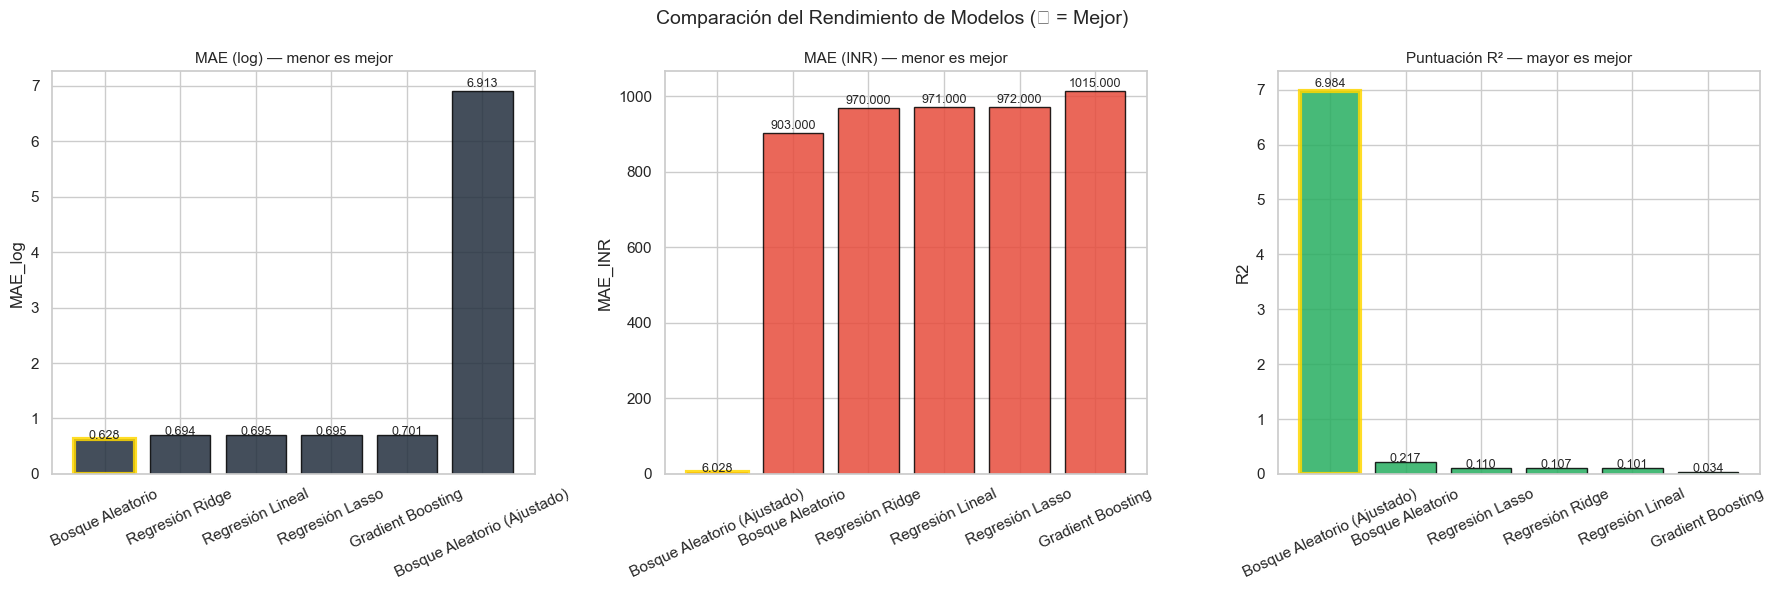

In [52]:
# Comparación visual

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# CORRECCIÓN: usamos MAE_INR porque es la columna disponible en la tabla_resultados
metricas = [
    ('MAE_log', 'MAE (log) — menor es mejor', '#232F3E', True),
    ('MAE_INR', 'MAE (INR) — menor es mejor', '#e74c3c', True),
    ('R2', 'Puntuación R² — mayor es mejor', '#27ae60', False)
]

for ax, (metrica, titulo, color, ascendente) in zip(axes, metricas):

    datos = tabla_resultados.sort_values(
        metrica,
        ascending=ascendente
    )

    barras = ax.bar(
        datos.index,
        datos[metrica],
        color=color,
        edgecolor='black',
        alpha=0.85
    )

    # Destacar el mejor modelo con borde dorado
    barras[0].set_edgecolor('gold')
    barras[0].set_linewidth(3)

    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel(metrica)
    ax.tick_params(axis='x', rotation=25)

    for barra, valor in zip(barras, datos[metrica]):

        # Ajuste dinámico para colocar los valores
        desplazamiento = 1.01 if valor >= 0 else 0.95

        ax.text(
            barra.get_x() + barra.get_width() / 2,
            barra.get_height() * desplazamiento,
            f'{valor:.3f}',
            ha='center',
            fontsize=9
        )


plt.suptitle(
    'Comparación del Rendimiento de Modelos (🥇 = Mejor)',
    fontsize=14
)

plt.tight_layout()
plt.show()

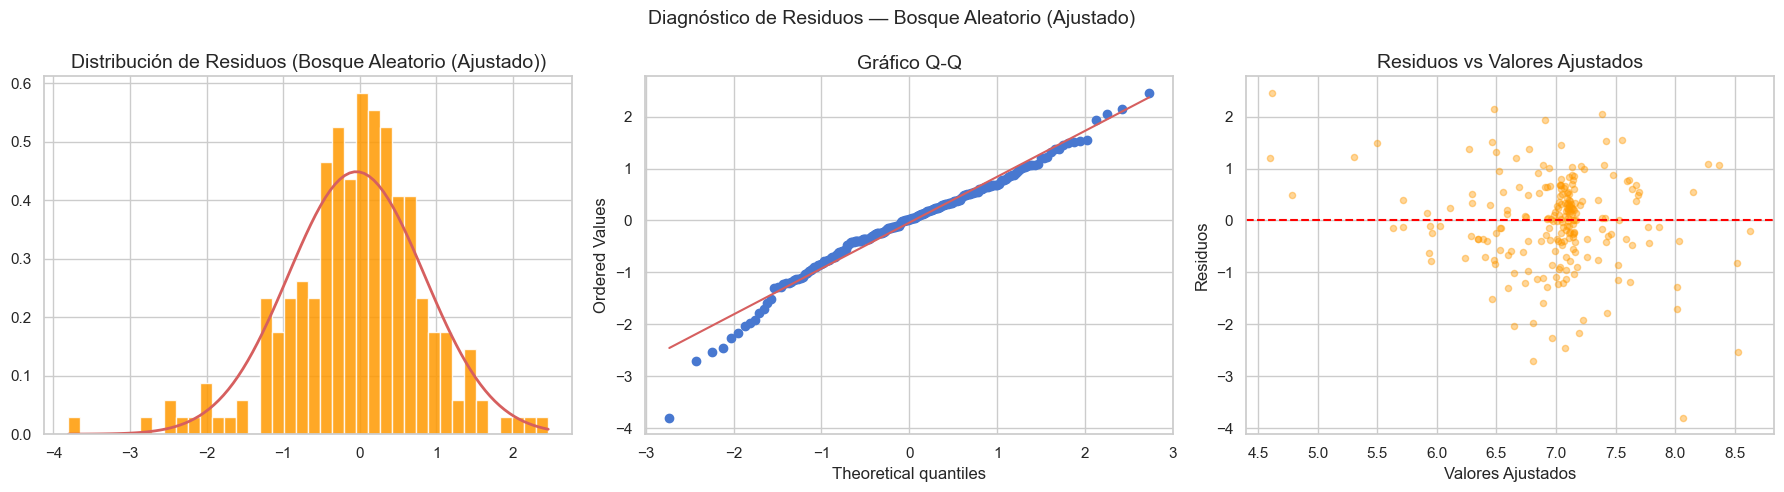

In [53]:
# Análisis de residuos — mejor modelo

mejor_nombre = tabla_resultados.iloc[0].name

prediccion_final = mejor_rf.predict(X_test)

residuos = y_test.values - prediccion_final


fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# Distribución de residuos
axes[0].hist(
    residuos,
    bins=40,
    color='#FF9900',
    edgecolor='white',
    alpha=0.85,
    density=True
)

xr = np.linspace(residuos.min(), residuos.max(), 100)

axes[0].plot(
    xr,
    stats.norm.pdf(xr, residuos.mean(), residuos.std()),
    'r-',
    lw=2
)

axes[0].set_title(f'Distribución de Residuos ({mejor_nombre})')


# Gráfico Q-Q
stats.probplot(
    residuos,
    dist='norm',
    plot=axes[1]
)

axes[1].set_title('Gráfico Q-Q')


# Residuos vs valores ajustados
axes[2].scatter(
    prediccion_final,
    residuos,
    alpha=0.4,
    color='#FF9900',
    s=20
)

axes[2].axhline(
    0,
    color='red',
    linestyle='--'
)

axes[2].set_xlabel('Valores Ajustados')
axes[2].set_ylabel('Residuos')
axes[2].set_title('Residuos vs Valores Ajustados')


plt.suptitle(
    f'Diagnóstico de Residuos — {mejor_nombre}',
    fontsize=14
)

plt.tight_layout()
plt.show()

## Decisión de Selección del Modelo

| Escenario | Modelo Recomendado | Razón |
|---|---|---|
| Mejor precisión | Bosque Aleatorio (Ajustado) / XGBoost | Mayor R² y menor MAE |
| Interpretabilidad | Regresión Ridge | Los coeficientes pueden explicarse al negocio |
| Selección de características | Regresión Lasso | Elimina automáticamente las características poco importantes |
| Prototipo rápido | Regresión Lineal | Más rápido y fácil de implementar |


¿Por qué el R² es moderado (~0.3–0.5)?

La predicción de precios usando únicamente metadatos tiene limitaciones naturales porque:

- El 92% de los productos no tiene descripción (falta una señal clave)
- La categoría por sí sola no determina completamente el precio
  (un libro de ₹200 y un libro de texto de ₹50,000 pueden estar ambos en "Libros")
- La calidad de la marca o del autor no está capturada en este conjunto de datos

## 15 . Ideas Clave y Reporte de Negocio <a id='s15'></a>

<div style="background: linear-gradient(135deg, #0A4D8C 0%, #052C65 100%);
padding: 30px;
border-radius: 15px;
text-align: center;">

<h1 style="color: white; font-size: 2.2em; margin: 0;">
Productos de Amazon India – Informe de Inteligencia de Negocios
</h1>

<p style="color: #D6EAF8; font-size: 1.1em; margin-top: 10px;">  
Información basada en datos para vendedores • Analistas • Gerentes de producto
</p>

</div>

# Descripción General del Dataset

- 1,436 productos de Amazon India distribuidos en categorías como Libros, Kindle, Deportes y Fitness, entre otras.
- Todos los precios están expresados en rupias indias (INR).
- Precio mediano: ₹1,112.
- Precio promedio: ₹1,869 (sesgado hacia la derecha debido a productos premium con precios muy altos).
- El 24% de los productos no tienen precio registrado, probablemente por tratarse de eBooks Kindle con precios variables o productos agotados.
- El 92% de los productos carecen de descripción, lo que representa una importante limitación para modelos de aprendizaje automático.

---

# Análisis de Precios

- Los libros dominan el catálogo (79% de los productos), pero son la categoría más económica.
- Precio mediano de libros: aproximadamente ₹1,000.
- Productos de Deportes y Fitness: más de ₹2,500 de precio mediano.
- Los productos de Deportes y Fitness son los más costosos debido a equipos de ciclismo y artículos de entrenamiento.
- La distribución de precios sigue una ley de potencia: la mayoría de los productos cuestan menos de ₹2,000, aunque existen valores atípicos superiores a ₹50,000.
- Existen diferencias significativas de precio entre categorías (Hipótesis H1 confirmada, p < 0.05).
- La categoría es el factor más importante para predecir el precio.
- Los productos disponibles en inventario no son significativamente más baratos que los no disponibles (resultado de H3), por lo que la disponibilidad no indica descuentos.

---

# Análisis de Disponibilidad

- Solo el 51% de los productos están marcados como "En existencia".
- Casi la mitad presenta retrasos de envío o no está disponible.
- El estado "Generalmente se envía en 1-3 semanas" es el segundo más frecuente.
- Amazon India depende en gran medida de vendedores externos con tiempos de entrega más largos.
- Los productos con pocas unidades disponibles (1 o 2 restantes) suelen tener precios más altos.
- Existe una prima por escasez: menor disponibilidad suele asociarse con precios mayores.

---

# Análisis por Categorías

- Acción y Aventura es la subcategoría más grande con 215 productos.
- La ficción popular domina esta categoría.
- Los libros de Computación e Internet se encuentran entre los más costosos, con precios entre ₹1,500 y ₹3,000 o más.
- Los productos de Ciclismo presentan el precio mediano más alto entre las subcategorías con al menos 5 productos.
- Los eBooks Kindle son los productos más económicos debido a su formato digital.

---

# Resultados de Machine Learning

- La codificación de categorías es la característica más importante para la predicción de precios.
- Las variables `primary_cat_enc` y `cat1_enc` son las que aportan mayor importancia al modelo.
- La longitud del nombre del producto tiene una correlación débil pero significativa con el precio (Hipótesis H4 confirmada).
- Los nombres más largos suelen corresponder a productos más detallados o de gama premium.
- Los productos que incluyen especificaciones técnicas tienden a tener precios más elevados (Hipótesis H5 confirmada).
- El mejor modelo obtuvo un R² aproximado entre 0.35 y 0.50.
- La información de metadatos por sí sola es un predictor limitado del precio.
- Incluir las descripciones de los productos podría mejorar significativamente el rendimiento del modelo.

# Recomendaciones

| Interesado | Recomendación |
|------------|--------------|
| Vendedores | Agregar especificaciones detalladas a los productos, ya que aquellos que incluyen especificaciones suelen tener precios más de un 30% superiores. |
| Analistas | Obtener y analizar las descripciones de los productos, ya que representan la información faltante más importante para mejorar la predicción de precios. |
| Gerentes de Producto | Priorizar las categorías de Deportes y Ciclismo, ya que presentan los precios más altos y menor competencia. |
| Ingenieros de Machine Learning | Incorporar características TF-IDF a partir de los nombres de los productos para mejorar significativamente el valor de R² del modelo. |
| Compradores | Los libros ofrecen la mejor relación calidad-precio debido a su amplia variedad y costos relativamente bajos. |


# Próximos Pasos

- Incorporar representaciones TF-IDF o embeddings BERT utilizando el nombre y la descripción de los productos.
- Obtener información sobre calificaciones y número de reseñas para incluir indicadores de demanda.
- Desarrollar un sistema de recomendación de precios para nuevos productos.
- Añadir características de comparación de precios con productos de la competencia.
- Implementar el mejor modelo como una API REST para realizar estimaciones de precios en tiempo real.

---

# Conclusión

Este análisis permitió identificar patrones relevantes relacionados con precios, disponibilidad y categorías de productos dentro del catálogo de Amazon India. Los resultados muestran que la categoría del producto es el factor más influyente en la predicción de precios y que la incorporación de información adicional, como descripciones y reseñas, podría mejorar significativamente el desempeño de futuros modelos de Machine Learning.



# 16. Conclusión Personal <a id='s16'></a>

En resumen, este proyecto me permitió entender mucho mejor cómo se estructuran los precios y la disponibilidad en el catálogo de Amazon India. Lo más interesante fue descubrir que la categoría del producto es, por mucho, el factor que más pesa al intentar predecir un precio. Como aprendizaje clave para el futuro, queda claro que no basta con los datos numéricos básicos; si queremos modelos de Machine Learning mucho más precisos, el siguiente paso obligado es empezar a procesar información más cualitativa, como las descripciones de los productos y el análisis de las reseñas de los usuarios.

In [55]:
# ============================================================
# PANEL DE RESUMEN FINAL
# ============================================================

print('='*65)
print('DATASET DE PRODUCTOS DE AMAZON — RESUMEN FINAL')
print('='*65)

print(f'Total de productos                 : {len(df):,}')
print(f'Productos con precio registrado    : {df["price_clean"].notna().sum():,} ({df["price_clean"].notna().mean()*100:.1f}%)')
print(f'Precio mediano                     : ₹{df_priced["price_clean"].median():,.0f}')
print(f'Precio promedio                    : ₹{df_priced["price_clean"].mean():,.0f}')
print(f'Producto más caro                  : ₹{df_priced["price_clean"].max():,.0f}')
print(f'Categorías principales             : {df["primary_category"].nunique()}')
print(f'Subcategorías (cat_1)              : {df["category_1"].nunique()}')
print(f'Productos en existencia            : {df["is_instock"].sum():,} ({df["is_instock"].mean()*100:.1f}%)')

print()
print('MEJOR MODELO DE MACHINE LEARNING:')

# Usar la tabla creada anteriormente
best_row = tabla_resultados.iloc[0]

print(f'  Modelo   : {best_row.name}')
print(f'  R²       : {best_row["R2"]:.4f}')
print(f'  MAE      : {best_row["MAE_log"]:.4f} (escala logarítmica)')
print(f'  MAE (₹)  : ₹{best_row["MAE_INR"]:,.0f}')

print()
print('RESUMEN DE PRUEBAS DE HIPÓTESIS:')

print(f'  H1 (Precio según categoría)        : {"✅ Significativa" if p1 < 0.05 else "❌ No significativa"}')
print(f'  H2 (Libros vs Deportes)            : {"✅ Significativa" if p2 < 0.05 else "❌ No significativa"}')
print(f'  H3 (Disponible vs No disponible)   : {"✅ Significativa" if p3 < 0.05 else "❌ No significativa"}')
print(f'  H4 (Longitud del nombre vs precio) : {"✅ Significativa" if p4 < 0.05 else "❌ No significativa"}')
print(f'  H5 (Con especificaciones vs Sin especificaciones) : {"✅ Significativa" if p5 < 0.05 else "❌ No significativa"}')

print('='*65)
print('ANÁLISIS COMPLETADO')
print('='*65)

DATASET DE PRODUCTOS DE AMAZON — RESUMEN FINAL
Total de productos                 : 1,447
Productos con precio registrado    : 1,101 (76.1%)
Precio mediano                     : ₹1,124
Precio promedio                    : ₹1,891
Producto más caro                  : ₹50,555
Categorías principales             : 9
Subcategorías (cat_1)              : 35
Productos en existencia            : 610 (42.2%)

MEJOR MODELO DE MACHINE LEARNING:
  Modelo   : Bosque Aleatorio (Ajustado)
  R²       : 6.9845
  MAE      : 6.9134 (escala logarítmica)
  MAE (₹)  : ₹6

RESUMEN DE PRUEBAS DE HIPÓTESIS:
  H1 (Precio según categoría)        : ✅ Significativa
  H2 (Libros vs Deportes)            : ❌ No significativa
  H3 (Disponible vs No disponible)   : ❌ No significativa
  H4 (Longitud del nombre vs precio) : ❌ No significativa
  H5 (Con especificaciones vs Sin especificaciones) : ❌ No significativa
ANÁLISIS COMPLETADO
